# Python Programming for Business Intelligence - Final Project
## Prepared by Daniil Ruzhinskii

# Statement of AI use

1. AI was used explicitly to prepare the function of imputing the columns with the waterfall priority in the step 2.3.3 and mapping the Rating values in the step 3.3.1

2. In general, AI was used for consulting purposes throughout the project to map the logical next steps of data pipeline and assitance with the proper handling of financial data related to fixed income. 

3. AI was also used in part of statistical analysis - selecting the hyperparameters and correct evaluation score from confusion matrix to benchmark the model. 

4. At the final stage, I needed help with the analysis of unsupervised learning results, as it was a bit complex to approach the plotting of the bond clusters. AI was used to produce grouped plots and the executive summary table code (part 7.2).

5. AI Chat GPT Image2 was used to produce the data pipeline sketch

# 0. Introduction

##### Goal
The goal of this project is to examine whether observable bond market features can be used to classify Nordic bonds into credit risk groups using real data extracted from the LSEG Refinitiv API. More specifically, the notebook aims to answer the following question:

Can bond-level market and instrument characteristics such as *yield to maturity, coupon, duration, spread, sector, currency, issuer country, and callable status* help classify bonds by credit rating or bond grade?

To answer this question, the project builds a bond-level dataset for instruments issued in Finland, Sweden, and Norway. The analysis focuses on fixed income instruments and uses data directly extracted from **LSEG** in order to practice working with a real financial API, handling imperfect data, and preparing a dataset for visual and quantitative analysis.

In practical terms, the notebook first identifies available bond instruments through discovery search, then extracts relevant reference and pricing-related fields, and finally combines these with supplementary data when some observations are missing from the primary source. After cleaning and transforming the data, the notebook explores the relationship between bond characteristics and rating-based risk categories using visual analysis and a simple machine learning classification approach.

##### How to use this notebook
This notebook is intended as both a project submission and a practical starting point for anyone who wants to begin working with the LSEG Refinitiv API in Python, especially in a fixed income context.

The notebook is structured so that each stage of the workflow is separated clearly:

- importing libraries and field definitions
- loading discovery search results
- combining bond files
- enriching missing fields from supplementary sources
- cleaning data
- performing exploratory data analysis
- classifying bond ratings (supervised ml) and classifying them into clusters (unsupervised ml)
- result summary

##### Who may benefit/scale
The notebook may be useful for students who are starting with LSEG data, because although LSEG provides documentation in its developer community and example code in GitHub repositories, it can still be difficult for a beginner to understand how to connect the different parts of the ecosystem smoothly in practice. The examples are either quite narrow or built by the seasoned financial software engineers, and building a working end-to-end workflow for fixed income data on beginner level usually requires additional trial and error. This notebook therefore aims to serve as a more practical and structured example of how to move from raw API extraction to a usable analytical dataset, though on a limited scale. 


##### Data pipeline snippet

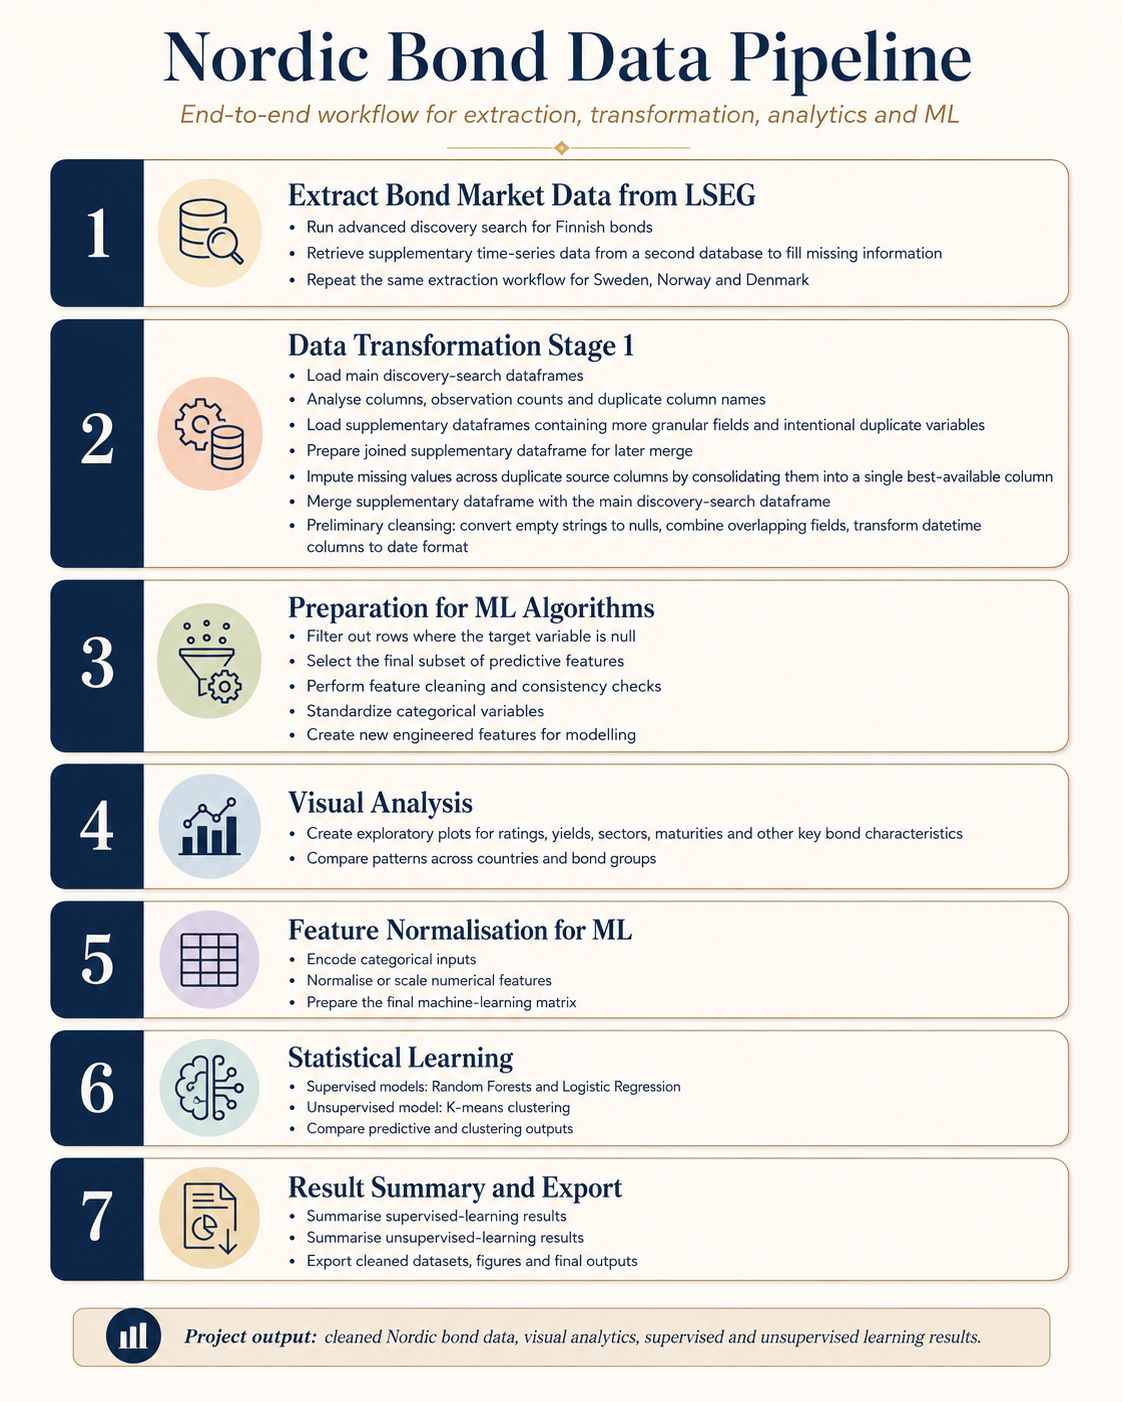

# 1. Data Extraction

## 1.1. Import libraries and modules

I have prepared the separate .py file with the list of the combined fields which LSEG offers at their extractions. This is much easier to use them as grouped objects to avoid unnecessary long strings in the API calls.

In [1]:
import json 
import pandas as pd
import lseg.data as ld
import refinitiv.data as rd

## 1.2. Load API and check the field groups

In [2]:
from dotenv import load_dotenv
import os

# Load all variables from .env into the environment
load_dotenv()

lseg_api = os.environ.get("LSEG_API")

if lseg_api:
    print(f"API Key loaded: {lseg_api[:5]}...")
else:
    print("ERROR: Check the correctness of the .env file)")


API Key loaded: f42c2...


In [ ]:
project_fields = [

    # Metadata fields
    "TR.RIC",
    "TR.FiCurrency",

    # Rating supplementary fields
    "TR.IssuerRating",              # Issuer rating
    "TR.IR.RatingSourceDescription", # Rating source,
    "TR.IR.RatingDate",             # Rating date

    "TR.FiFItchsRating",                # Fitch rating
    "TR.FiFItchsRatingDate",
    "TR.FiSPRating",                    # S&P rating
    "TR.FiSPRatingDate",               
    "TR.FiMoodysRating",
    "TR.FiMoodysRatingDate",


    # Duration supplementary fields
    "TR.DurationAnalytics",         # Duration
    "TR.TOTALDURATION",

    "TR.ModifiedDurationAnalytics", # Modified duration
    "TR.MODIFIEDDURATION",

    "TR.FiMaturityCorpMacDuration",
    "TR.MACAULAYDURATION",
    
    # YTM Supplementary fields
    "TR.FiMaturityStandardYield",   # Yield to maturity (YTM)
    "TR.YIELDTOMATURITY",           # Second field of YTM, trying several which will succeed better
    "TR.AVERAGEYIELDTOMATURITY",
    "TR.YieldToMaturityAnalytics",
    
    "TR.FiBondGrade",
    "TR.FiParValue",
    "TR.FiFaceIssuedTotal"
]

## 1.3. Perform the Corporate and Gov bond search in Finland

### 1.3.1. Discovery search

In [4]:
ld.open_session()

<lseg.data.session.Definition object at 0x169887920 {name='workspace'}>

In [5]:
corp_bond_search_fi = ld.discovery.search(
	view = ld.discovery.Views.GOV_CORP_INSTRUMENTS,
	top = 500,
	filter = "(DbType eq 'CORP' and IsActive eq true and (RCSCountryGenealogy in ('G:90')))",
	select = "RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate",
	order_by = "RIC"
)

In [ ]:
display(corp_bond_search_fi.head(-5))
#corp_bond_search_fi.to_csv("corp_bond_search_fi.csv")

,RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate
0,DEA19JHQ=,OP Asuntoluottopankki Oyj,OPCPRO,0.75,2027-06-07,2017-06-07,XS1626141698,Euro,Finland,Corporate,Covered Bond (Other),Investment Grade,2.809048,1.081293,1.066398,False,Mortgage Banking,97.818,2026-05-01
1,DEA1ZYKN=,Nordea Kiinnitysluottopankki Oyj,NDAFTI,0.625,2027-03-17,2015-03-17,XS1204140971,Euro,Finland,Corporate,Covered Bond (Other),Investment Grade,2.650345,0.866667,0.847227,False,Banking,98.284,2026-05-01
2,DEA285A2=,OP Asuntoluottopankki Oyj,OPCPRO,0.01,2030-11-19,2020-11-19,XS2260183285,Euro,Finland,Corporate,Covered Bond (Other),Investment Grade,3.088424,4.537793,4.469249,False,Mortgage Banking,87.137,2026-05-01
3,DEA28SAX=,OP Asuntoluottopankki Oyj,OPCPRO,0.05,2028-04-21,2020-01-21,XS2105779719,Euro,Finland,Corporate,Covered Bond (Other),Investment Grade,2.949654,1.960597,1.932298,False,Mortgage Banking,94.551,2026-05-01
4,DEA2R3NS=,Nordea Kiinnitysluottopankki Oyj,NDAFTI,0.125,2027-06-18,2019-06-18,XS2013525410,Euro,Finland,Corporate,Covered Bond (Other),Investment Grade,2.754494,1.118163,1.10306,False,Banking,97.137,2026-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,XS3330368518=,Nordea Kiinnitysluottopankki Oyj,NDAFTI,2.875,2029-04-03,2026-04-01,XS3330368518,Euro,Finland,Corporate,Covered Bond (Other),Investment Grade,2.947038,2.827664,2.78688,False,Banking,99.798,2026-05-01
330,<NA>,OP-Henkivakuutus Oy,OPOSUL,6.427,NaT,1999-10-27,FI0003009001,Euro,Finland,Corporate,Note,<NA>,<NA>,<NA>,<NA>,True,Life Insurance,<NA>,NaT
331,<NA>,Taaleri Kiinteistokehitys C-Sarja Ky,TAKOH,0.0,NaT,2015-08-17,FI4000167036,Euro,Finland,Corporate,Bond,<NA>,<NA>,<NA>,<NA>,True,Financial - Other,<NA>,NaT
332,<NA>,OP-Henkivakuutus Oy,OPOSUL,6.289,NaT,2001-09-17,FI0002001868,Euro,Finland,Corporate,Bond,<NA>,<NA>,<NA>,<NA>,True,Life Insurance,<NA>,NaT


In [7]:
gov_bond_search_fi = ld.discovery.search(
	view = ld.discovery.Views.GOV_CORP_INSTRUMENTS,
	top = 500,
	filter = "(DbType eq 'GOVT' and IsActive eq true and (RCSCountryGenealogy in ('G:90')))",
	select = "RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate",
	order_by = "RIC"
)

In [ ]:
display(gov_bond_search_fi.head(-5))
#gov_bond_search_fi.to_csv("gov_bond_search_fi.csv")

,RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate
0,FI0037635=,"Finland, Republic of (Government)",FINL,2.75,2028-07-04,2012-02-07,FI4000037635,Euro,Finland,Govt/Treasury/Central Bank,Bond,Investment Grade,2.649391,2.084437,2.057355,False,Sovereign,100.204,2026-05-01
1,FI0046545=,"Finland, Republic of (Government)",FINL,2.625,2042-07-04,2012-07-03,FI4000046545,Euro,Finland,Govt/Treasury/Central Bank,Bond,Investment Grade,3.697974,12.817836,12.587204,False,Sovereign,87.111,2026-05-01
2,FI0148630=,"Finland, Republic of (Government)",FINL,0.75,2031-04-15,2015-03-10,FI4000148630,Euro,Finland,Govt/Treasury/Central Bank,Bond,Investment Grade,2.948942,4.865708,4.795503,False,Sovereign,90.017,2026-05-01
3,FI0242870=,"Finland, Republic of (Government)",FINL,1.375,2047-04-15,2017-02-15,FI4000242870,Euro,Finland,Govt/Treasury/Central Bank,Bond,Investment Grade,3.84727,17.512831,17.185353,False,Sovereign,64.882,2026-05-01
4,FI0278551=,"Finland, Republic of (Government)",FINL,0.5,2027-09-15,2017-09-06,FI4000278551,Euro,Finland,Govt/Treasury/Central Bank,Bond,Investment Grade,2.676585,1.356028,1.338195,False,Sovereign,97.12,2026-05-01
5,FI0306758=,"Finland, Republic of (Government)",FINL,1.125,2034-04-15,2018-02-13,FI4000306758,Euro,Finland,Govt/Treasury/Central Bank,Bond,Investment Grade,3.21368,7.608754,7.489351,False,Sovereign,85.556,2026-05-01
6,FI0348727=,"Finland, Republic of (Government)",FINL,0.5,2028-09-15,2018-09-04,FI4000348727,Euro,Finland,Govt/Treasury/Central Bank,Bond,Investment Grade,2.740892,2.345656,2.314112,False,Sovereign,94.935,2026-05-01
7,FI0369467=,"Finland, Republic of (Government)",FINL,0.5,2029-09-15,2019-02-12,FI4000369467,Euro,Finland,Govt/Treasury/Central Bank,Bond,Investment Grade,2.814747,3.329749,3.283809,False,Sovereign,92.666,2026-05-01
8,FI0415153=,"Finland, Republic of (Government)",FINL,0.125,2036-04-15,2020-02-11,FI4000415153,Euro,Finland,Govt/Treasury/Central Bank,Bond,Investment Grade,3.39851,9.875749,9.712082,False,Sovereign,72.762,2026-05-01
9,FI0440557=,"Finland, Republic of (Government)",FINL,0.25,2040-09-15,2020-06-17,FI4000440557,Euro,Finland,Govt/Treasury/Central Bank,Bond,Investment Grade,3.679606,14.00356,13.752763,False,Sovereign,62.258,2026-05-01


### 1.3.2. Supplementary data missing from discovery search

In [ ]:
bond_ric_list_fi = corp_bond_search_fi.iloc[:,0].astype(str).tolist() + gov_bond_search_fi.iloc[:,0].astype(str).tolist()
bond_ric_list_fi

['DEA19JHQ=',
 'DEA1ZYKN=',
 'DEA285A2=',
 'DEA28SAX=',
 'DEA2R3NS=',
 'DEA2RXT8=',
 'DEA3LTE7=',
 'DK267356483=',
 'FI0003030544=',
 'FI261383829=',
 'FI271729278=',
 'FI4000024179=',
 'FI4000149976=',
 'FI4000282629=',
 'FI4000292180=',
 'FI4000353099=',
 'FI4000384185=',
 'FI4000386446=',
 'FI4000387279=',
 'FI4000399696=',
 'FI4000410915=',
 'FI4000440276=',
 'FI4000440342=HE',
 'FI4000440789=HE',
 'FI4000441753=',
 'FI4000441803=HE',
 'FI4000441811=HE',
 'FI4000441936=HE',
 'FI4000442108=',
 'FI4000442264=',
 'FI4000442314=HE',
 'FI4000442322=HE',
 'FI4000456090=',
 'FI4000456173=HE',
 'FI4000456199=HE',
 'FI4000466412=',
 'FI4000466438=HE',
 'FI4000466453=HE',
 'FI4000466602=HE',
 'FI4000466651=',
 'FI4000476791=',
 'FI4000476940=HE',
 'FI4000476957=HE',
 'FI4000480041=HE',
 'FI4000480058=HE',
 'FI4000480116=',
 'FI4000480371=',
 'FI4000480405=HE',
 'FI4000480439=HE',
 'FI4000480447=HE',
 'FI4000480520=HE',
 'FI4000480538=HE',
 'FI4000480561=',
 'FI4000490628=HE',
 'FI4000490719=

In [18]:
supplementary_fi = ld.get_data(
    universe=bond_ric_list_fi,
    fields=project_fields,
    parameters = {'SDate': '0CY', 'Curn': 'EUR'}
)

/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_access_layer/_containers.py:62:UserWarning: You have duplicated instruments in your input. Output will contain unique instruments only.
/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behav

In [ ]:
display(supplementary_fi.head(-5))
#supplementary_fi.to_csv("supplementary_fi.csv")

,Instrument,RIC,Currency,Issuer Rating,Rating Source Description,Date,Fitchs Rating,Fitchs Rating Date,SP Rating,SP Rating Date,...,Modified Duration,Mac. Duration,Macaulay Duration,Yield To Maturity,Yield to Maturity,Average Yield to Maturity,Yield to Maturity,Bond Grade,Par Value,Face Issued Total
0,DEA19JHQ=,DEA19JHQ=,EUR,Aaa,Moody's Long-term Mortgage Covered Bonds Rating,2014-11-28,,NaT,<NA>,NaT,...,1.3803,1.081293,<NA>,2.809048,<NA>,,2.80712,Bond Grade: Investment Grade,1000,1000000000
1,DEA1ZYKN=,DEA1ZYKN=,EUR,AA (low),Dominion Bond Rating Service (DBRS) - Long-ter...,2018-12-07,,NaT,<NA>,NaT,...,1.1639,0.866667,<NA>,2.650345,<NA>,,2.793457,Bond Grade: Investment Grade,1000,1000000000
2,DEA285A2=,DEA285A2=,EUR,Aaa,Moody's Long-term Mortgage Covered Bonds Rating,2014-11-28,,NaT,<NA>,NaT,...,4.7371,4.537793,<NA>,3.088424,<NA>,,3.077096,Bond Grade: Investment Grade,1000,1250000000
3,DEA28SAX=,DEA28SAX=,EUR,Aaa,Moody's Long-term Mortgage Covered Bonds Rating,2014-11-28,,NaT,<NA>,NaT,...,2.2345,1.960597,<NA>,2.949654,<NA>,,2.931615,Bond Grade: Investment Grade,1000,1000000000
4,DEA2R3NS=,DEA2R3NS=,EUR,AA (low),Dominion Bond Rating Service (DBRS) - Long-ter...,2018-12-07,,NaT,<NA>,NaT,...,1.4181,1.118163,<NA>,2.754494,<NA>,,2.726181,Bond Grade: Investment Grade,1000,1000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,FI0587415=,FI0587415=,EUR,AA,Fitch Long-term Issuer Default Rating,2025-07-25,AA,2025-07-25,<NA>,NaT,...,8.2096,8.126457,<NA>,3.331372,<NA>,,3.328299,Bond Grade: Investment Grade,1000,9054000000
356,FI0590971=,FI0590971=,EUR,AA,Fitch Long-term Issuer Default Rating,2025-07-25,,NaT,<NA>,NaT,...,0.3483,0.022222,<NA>,2.046107,<NA>,,2.000176,,1000,7297000000
357,FI0591862=,FI0591862=,EUR,AA,Fitch Long-term Issuer Default Rating,2025-07-25,AA,2025-08-28,<NA>,NaT,...,5.6497,5.568703,<NA>,3.029148,<NA>,,3.010467,Bond Grade: Investment Grade,1000,4698000000
358,FI0592183=,FI0592183=,EUR,AA,Fitch Long-term Issuer Default Rating,2025-07-25,,NaT,<NA>,NaT,...,0.5987,0.272222,<NA>,2.267905,<NA>,,2.2031,,1000,5218000000


## 1.4. Perform same bond extraction for Sweden

In [21]:
corp_bond_search_se = ld.discovery.search(
	view = ld.discovery.Views.GOV_CORP_INSTRUMENTS,
	top = 500,
	filter = "((DbType eq 'CORP') and IsActive eq true and (RCSCountryGenealogy in ('G:6V')))",
	select = "RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate",
	order_by = "RIC"
)

In [ ]:
display(corp_bond_search_se.head(-5))
#corp_bond_search_se.to_csv("corp_bond_search_se.csv")

,RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate
0,DEA285GL=,Stadshypotek AB,SHBST,0.01,2028-11-24,2020-11-24,XS2262802601,Euro,Sweden,Corporate,Covered Bond (Other),Investment Grade,2.947862,2.552463,2.515605,False,Mortgage Banking,92.867,2026-05-01
1,DEA3KSG2=,AB Sveriges Sakerstallda Obligationer (publ),SBABS,0.01,2030-03-14,2021-06-14,XS2353010593,Euro,Sweden,Corporate,Sakerstallda Obligation (Covered Bond),Investment Grade,3.02591,3.85769,3.800629,False,Financial - Other,89.173,2026-05-01
2,DEA3KWUS=,Stadshypotek AB,SHBST,0.01,2030-09-30,2021-09-30,XS2391570418,Euro,Sweden,Corporate,Covered Bond (Other),Investment Grade,3.024998,4.401684,4.336543,False,Mortgage Banking,87.737,2026-05-01
3,DEA3LESB=,Skandinaviska Enskilda Banken AB,SEB,3.25,2028-05-04,2023-02-27,XS2592234749,Euro,Sweden,Corporate,Sakerstallda Obligation (Covered Bond),Investment Grade,2.907626,1.965846,1.937875,False,Banking,100.655,2026-05-01
4,DEA3LF3E=,Stadshypotek AB,SHBST,3.125,2028-04-04,2023-04-04,XS2607344079,Euro,Sweden,Corporate,Sakerstallda Obligation (Covered Bond),Investment Grade,2.910242,1.883647,1.856805,False,Mortgage Banking,100.391,2026-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,SE0013884566=,Hufvudstaden AB,HUFV,3.888,2028-01-18,2024-01-18,SE0013884566,Swedish Krona,Sweden,Corporate,Bond,<NA>,3.113467,1.665622,1.640282,False,Leasing,101.253,2026-05-01
491,SE0013884582=,Ziklo Bank AB,ZKLOK,3.016,2027-01-26,2024-01-26,SE0013884582,Swedish Krona,Sweden,Corporate,Bond,<NA>,2.498345,0.719377,0.227778,False,Banking,100.402,2026-05-01
492,SE0013884590=,Ziklo Bank AB,ZKLOK,3.346,2029-01-26,2024-01-26,SE0013884590,Swedish Krona,Sweden,Corporate,Bond,<NA>,2.819508,2.613528,0.227778,False,Banking,101.496,2026-05-01
493,SE0013884608=,Afry AB,AFRY,3.97,2029-02-27,2024-02-27,SE0013884608,Swedish Krona,Sweden,Corporate,Bond,<NA>,3.404975,2.650647,0.061111,False,Service - Other,102.004,2026-05-01


In [23]:
gov_bond_search_se = ld.discovery.search(
	view = ld.discovery.Views.GOV_CORP_INSTRUMENTS,
	top = 500,
	filter = "(DbType eq 'GOVT' and IsActive eq true and (RCSCountryGenealogy in ('G:6V')))",
	select = "RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate",
	order_by = "RIC"
)

In [ ]:
display(gov_bond_search_se.head(-5))
#gov_bond_search_se.to_csv("gov_bond_search_se.csv")

,RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate
0,SE1053=,"Sweden, Kingdom of (Government)",SWED,3.5,2039-03-30,2009-03-30,SE0002829192,Swedish Krona,Sweden,Govt/Treasury/Central Bank,Bond,Investment Grade,2.980522,10.639007,10.483916,False,Sovereign,105.493,2026-05-01
1,SE1056=,"Sweden, Kingdom of (Government)",SWED,2.25,2032-06-01,2012-03-20,SE0004517290,Swedish Krona,Sweden,Govt/Treasury/Central Bank,Bond,Investment Grade,2.633445,5.620084,5.547513,False,Sovereign,97.872,2026-05-01
2,SE1059=,"Sweden, Kingdom of (Government)",SWED,1.0,2026-11-12,2015-05-22,SE0007125927,Swedish Krona,Sweden,Govt/Treasury/Central Bank,Bond,<NA>,2.186897,0.519444,0.51361,False,Sovereign,99.385,2026-05-01
3,SE1060=,"Sweden, Kingdom of (Government)",SWED,0.75,2028-05-12,2017-01-27,SE0009496367,Swedish Krona,Sweden,Govt/Treasury/Central Bank,Bond,<NA>,2.480409,1.996533,1.972224,False,Sovereign,96.632,2026-05-01
4,SE1061=,"Sweden, Kingdom of (Government)",SWED,0.75,2029-11-12,2018-06-01,SE0011281922,Swedish Krona,Sweden,Govt/Treasury/Central Bank,Bond,<NA>,2.549451,3.473156,3.429712,False,Sovereign,94.013,2026-05-01
5,SE1062=,"Sweden, Kingdom of (Government)",SWED,0.125,2031-05-12,2020-03-27,SE0013935319,Swedish Krona,Sweden,Govt/Treasury/Central Bank,Bond,<NA>,2.640299,4.998968,4.934253,False,Sovereign,88.319,2026-05-01
6,SE1063=,"Sweden, Kingdom of (Government)",SWED,0.5,2045-11-24,2020-11-24,SE0015193313,Swedish Krona,Sweden,Govt/Treasury/Central Bank,Bond,<NA>,3.076711,18.300405,18.025213,False,Sovereign,62.557,2026-05-01
7,SE1064=,"Sweden, Kingdom of (Government)",SWED,1.375,2071-06-23,2021-06-23,SE0016102115,Swedish Krona,Sweden,Govt/Treasury/Central Bank,Bond,<NA>,3.320976,28.545912,28.0834,False,Sovereign,54.813,2026-05-01
8,SE1065=,"Sweden, Kingdom of (Government)",SWED,1.75,2033-11-11,2022-05-06,SE0017830730,Swedish Krona,Sweden,Govt/Treasury/Central Bank,Bond,<NA>,2.747837,7.029989,6.935349,False,Sovereign,93.3,2026-05-01
9,SE1066=,"Sweden, Kingdom of (Government)",SWED,2.25,2035-05-11,2024-02-02,SE0021308541,Swedish Krona,Sweden,Govt/Treasury/Central Bank,Bond,<NA>,2.831067,8.24222,8.127969,False,Sovereign,95.433,2026-05-01


In [25]:
bond_ric_list_se = corp_bond_search_se.iloc[:,0].astype(str).tolist() + gov_bond_search_se.iloc[:,0].astype(str).tolist()

In [27]:
supplementary_se = ld.get_data(
    universe=bond_ric_list_se,
    fields=project_fields,
    parameters = {'SDate': '0CY', 'Curn': 'EUR'}
)

/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `

In [ ]:
display(supplementary_se.head(-5))
#supplementary_se.to_csv("supplementary_se.csv")

,Instrument,RIC,Currency,Issuer Rating,Rating Source Description,Date,Fitchs Rating,Fitchs Rating Date,SP Rating,SP Rating Date,...,Modified Duration,Mac. Duration,Macaulay Duration,Yield To Maturity,Yield to Maturity,Average Yield to Maturity,Yield to Maturity,Bond Grade,Par Value,Face Issued Total
0,DEA285GL=,DEA285GL=,EUR,P-1,Moody's Short-term Issuer Counterparty Risk Ra...,2018-06-26,,NaT,<NA>,NaT,...,2.8145,2.552463,<NA>,2.947862,,,2.937672,Bond Grade: Investment Grade,1000,1000000000
1,DEA3KSG2=,DEA3KSG2=,EUR,Aaa,Moody's Long-term Other Covered Bonds Rating,2018-10-16,,NaT,<NA>,NaT,...,4.0761,3.85769,<NA>,3.02591,,,3.00585,Bond Grade: Investment Grade,1000,1000000000
2,DEA3KWUS=,DEA3KWUS=,EUR,P-1,Moody's Short-term Issuer Counterparty Risk Ra...,2018-06-26,,NaT,<NA>,NaT,...,4.608,4.401684,<NA>,3.024998,,,2.996095,Bond Grade: Investment Grade,1000,1000000000
3,DEA3LESB=,DEA3LESB=,EUR,AA-,Fitch Senior Non-Preferred,2025-05-19,,NaT,<NA>,NaT,...,2.1907,1.965846,<NA>,2.907626,,,2.892549,Bond Grade: Investment Grade,1000,1500000000
4,DEA3LF3E=,DEA3LF3E=,EUR,P-1,Moody's Short-term Issuer Counterparty Risk Ra...,2018-06-26,,NaT,<NA>,NaT,...,2.1129,1.883647,<NA>,2.910242,,,2.879879,Bond Grade: Investment Grade,1000,1000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517,SE2612T=,SE2612T=,SEK,AAA,R&I Long-term Issuer Rating,2025-01-27,,NaT,<NA>,NaT,...,0.087109,0.613889,<NA>,2.240542,,,1.0,,5000,35000000000
518,SE2703T=,SE2703T=,SEK,AAA,R&I Long-term Issuer Rating,2025-01-27,,NaT,<NA>,NaT,...,<NA>,0.866667,<NA>,2.368887,,,1.0,,5000,23100000000
519,SE3103=,SE3103=,SEK,AAA,R&I Long-term Issuer Rating,2025-01-27,,NaT,<NA>,NaT,...,<NA>,2.473485,0.259986,2.468604,,,25.342186,,5000,3495210000
520,SE3104=,SE3104=,SEK,AAA,R&I Long-term Issuer Rating,2025-01-27,AAA,2004-08-06,<NA>,NaT,...,<NA>,2.475343,0.260134,1.238556,,,23.137764,Bond Grade: Investment Grade,5000,118230415000


## 1.5. Perform same bond extraction for Norway

In [29]:
corp_bond_search_no = ld.discovery.search(
	view = ld.discovery.Views.GOV_CORP_INSTRUMENTS,
	top = 500,
	filter = "((DbType eq 'CORP') and IsActive eq true and (RCSCountryGenealogy in ('G:3N')))",
	select = "RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate",
	order_by = "RIC"
)

In [ ]:
display(corp_bond_search_no.head(-5))
#corp_bond_search_no.to_csv("corp_bond_search_no.csv")

,RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate
0,DEA185JS=,Sparebank 1 Boligkreditt AS,SPRBG,0.25,2026-08-30,2016-08-30,XS1482554075,Euro,Norway,Corporate,Covered Bond (Other),Investment Grade,2.415126,0.319444,0.31699,False,Mortgage Banking,99.31,2026-05-01
1,DEA185TU=,DNB Boligkreditt AS,DNBDB,0.25,2026-09-07,2016-09-07,XS1485596511,Euro,Norway,Corporate,Covered Bond (Other),Investment Grade,2.421796,0.338889,0.336101,False,Financial - Other,99.261,2026-05-01
2,DEA282SD=,Sparebank 1 Boligkreditt AS,SPRBG,0.01,2027-09-22,2020-09-22,XS2234568983,Euro,Norway,Corporate,Covered Bond (Other),Investment Grade,2.832195,1.380453,1.361268,False,Mortgage Banking,96.223,2026-05-01
3,DEA2RW3D=,Sparebank 1 Boligkreditt AS,SPRBG,1.0,2029-01-30,2019-01-30,XS1943561883,Euro,Norway,Corporate,Covered Bond (Other),Investment Grade,2.953697,2.705559,2.666414,False,Mortgage Banking,94.927,2026-05-01
4,DEA3K1DE=,Sparebank 1 Boligkreditt AS,SPRBG,0.125,2028-01-20,2022-01-20,XS2434677998,Euro,Norway,Corporate,Covered Bond (Other),Investment Grade,2.884454,1.70705,1.682895,False,Mortgage Banking,95.453,2026-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,NO1101370=,Orkla ASA,ORK,4.8,2028-06-07,2021-06-07,NO0011013708,Norwegian Krone,Norway,Corporate,Bond,<NA>,4.961666,1.979362,0.091667,False,Conglomerate/Diversified Mfg,100.39,2026-05-01
491,NO1101371=,Orkla ASA,ORK,2.4425,2031-06-04,2021-06-04,NO0011013716,Norwegian Krone,Norway,Corporate,Bond,<NA>,5.384815,4.699457,4.577777,False,Conglomerate/Diversified Mfg,87.21,2026-05-01
492,NO1101603=,Bien Sparebank ASA,BIEN,5.13,2026-08-03,2021-06-03,NO0011016032,Norwegian Krone,Norway,Corporate,Bond,<NA>,4.769368,0.244444,0.244444,False,Banking,100.0,2026-05-01
493,NO1101712=,Skagerrak Sparebank,SPARBS,4.75,2026-06-08,2021-06-08,NO0011017121,Norwegian Krone,Norway,Corporate,Bond,<NA>,4.306814,0.091667,0.091667,False,Banking,100.04,2026-05-01


In [31]:
gov_bond_search_no = ld.discovery.search(
	view = ld.discovery.Views.GOV_CORP_INSTRUMENTS,
	top = 500,
	filter = "(DbType eq 'GOVT' and IsActive eq true and (RCSCountryGenealogy in ('G:3N')))",
	select = "RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate",
	order_by = "RIC"
)

In [ ]:
display(gov_bond_search_no.head(-5))
#gov_bond_search_no.to_csv("gov_bond_search_no.csv")

,RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate
0,NO0010786288=,"Norway, Kingdom Of (Government)",NORWAY,1.75,2027-02-17,2017-02-17,NO0010786288,Norwegian Krone,Norway,Govt/Treasury/Central Bank,Bond,Investment Grade,4.475805,0.783333,0.756613,False,Sovereign,97.91,2026-05-01
1,NO0010821598=,"Norway, Kingdom Of (Government)",NORWAY,2.0,2028-04-26,2018-04-26,NO0010821598,Norwegian Krone,Norway,Govt/Treasury/Central Bank,Bond,Investment Grade,4.614443,1.9549,1.911299,False,Sovereign,95.17,2026-05-01
2,NO0010844079=,"Norway, Kingdom Of (Government)",NORWAY,1.75,2029-09-06,2019-03-06,NO0010844079,Norwegian Krone,Norway,Govt/Treasury/Central Bank,Bond,Investment Grade,4.594938,3.227579,3.155888,False,Sovereign,91.38,2026-05-01
3,NO0010875230=,"Norway, Kingdom Of (Government)",NORWAY,1.375,2030-08-19,2020-02-19,NO0010875230,Norwegian Krone,Norway,Govt/Treasury/Central Bank,Bond,Investment Grade,4.56699,4.142544,4.051071,False,Sovereign,87.813,2026-05-01
4,NO0010930522=,"Norway, Kingdom Of (Government)",NORWAY,1.25,2031-09-17,2021-02-17,NO0010930522,Norwegian Krone,Norway,Govt/Treasury/Central Bank,Bond,Investment Grade,4.47125,5.163288,5.051588,False,Sovereign,84.924,2026-05-01
5,NO0012440397=,"Norway, Kingdom Of (Government)",NORWAY,2.125,2032-05-18,2022-02-16,NO0012440397,Norwegian Krone,Norway,Govt/Treasury/Central Bank,Bond,Investment Grade,4.445564,5.574683,5.454754,False,Sovereign,87.944,2026-05-01
6,NO0012712506=,"Norway, Kingdom Of (Government)",NORWAY,3.5,2042-10-06,2022-10-06,NO0012712506,Norwegian Krone,Norway,Govt/Treasury/Central Bank,Bond,Investment Grade,4.462802,12.232147,11.968008,False,Sovereign,88.95,2026-05-01
7,NO0012837642=,"Norway, Kingdom Of (Government)",NORWAY,3.0,2033-08-15,2023-02-15,NO0012837642,Norwegian Krone,Norway,Govt/Treasury/Central Bank,Bond,Investment Grade,4.396221,6.462024,6.324499,False,Sovereign,91.454,2026-05-01
8,NO0013148338=,"Norway, Kingdom Of (Government)",NORWAY,3.625,2034-04-13,2024-02-13,NO0013148338,Norwegian Krone,Norway,Govt/Treasury/Central Bank,Bond,Investment Grade,4.390702,6.996399,6.847683,False,Sovereign,94.958,2026-05-01
9,NO0013238246=,"Norway, Kingdom Of (Government)",NORWAY,3.625,2039-05-31,2024-05-31,NO0013238246,Norwegian Krone,Norway,Govt/Treasury/Central Bank,Bond,Investment Grade,4.466782,10.14362,9.924391,False,Sovereign,91.79,2026-05-01


In [33]:
bond_ric_list_no = corp_bond_search_no.iloc[:,0].astype(str).tolist() + gov_bond_search_no.iloc[:,0].dropna().astype(str).tolist()

In [34]:
supplementary_no = ld.get_data(
    universe=bond_ric_list_no,
    fields=project_fields,
    parameters = {'SDate': '0CY', 'Curn': 'EUR'}
)

/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `

In [ ]:
display(supplementary_no.head(-5))
#supplementary_no.to_csv("supplementary_no.csv")

,Instrument,RIC,Currency,Issuer Rating,Rating Source Description,Date,Fitchs Rating,Fitchs Rating Date,SP Rating,SP Rating Date,...,Modified Duration,Mac. Duration,Macaulay Duration,Yield To Maturity,Yield to Maturity,Average Yield to Maturity,Yield to Maturity,Bond Grade,Par Value,Face Issued Total
0,DEA185JS=,DEA185JS=,EUR,Aa3(cr),Moody's Long-term Counterparty Risk Assessment,2023-11-03,WD,2017-10-25,<NA>,NaT,...,0.6406,0.319444,<NA>,2.415126,<NA>,,2.416706,Bond Grade: Investment Grade,1000,1000000000
1,DEA185TU=,DEA185TU=,EUR,WR,Moody's Long-term Other Covered Bonds Rating,2018-12-20,,NaT,<NA>,NaT,...,0.6618,0.338889,<NA>,2.421796,<NA>,,2.375904,Bond Grade: Investment Grade,1000,1500000000
2,DEA282SD=,DEA282SD=,EUR,Aa3(cr),Moody's Long-term Counterparty Risk Assessment,2023-11-03,,NaT,<NA>,NaT,...,1.674,1.380453,<NA>,2.832195,<NA>,,2.83992,Bond Grade: Investment Grade,1000,1000000000
3,DEA2RW3D=,DEA2RW3D=,EUR,Aa3(cr),Moody's Long-term Counterparty Risk Assessment,2023-11-03,,NaT,<NA>,NaT,...,2.9337,2.705559,<NA>,2.953697,<NA>,,2.939927,Bond Grade: Investment Grade,1000,1250000000
4,DEA3K1DE=,DEA3K1DE=,EUR,Aa3(cr),Moody's Long-term Counterparty Risk Assessment,2023-11-03,,NaT,<NA>,NaT,...,1.9911,1.70705,<NA>,2.884454,<NA>,,2.869344,Bond Grade: Investment Grade,1000,1250000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,NO0012837642=,NO0012837642=,NOK,AAA,JCR Long-term Issuer Rating,2025-09-19,,NaT,<NA>,NaT,...,0.55489,6.462024,<NA>,4.396221,<NA>,,4.372773,Bond Grade: Investment Grade,1000,59098000000
511,NO0013148338=,NO0013148338=,NOK,AAA,JCR Long-term Issuer Rating,2025-09-19,,NaT,<NA>,NaT,...,0.576028,6.996399,<NA>,4.390702,<NA>,,4.370182,Bond Grade: Investment Grade,1000,52430000000
512,NO0013238246=,NO0013238246=,NOK,AAA,JCR Long-term Issuer Rating,2025-09-19,,NaT,<NA>,NaT,...,0.855688,10.14362,<NA>,4.466782,<NA>,,4.446731,Bond Grade: Investment Grade,1000,32481000000
513,NO0013475558=,NO0013475558=,NOK,AAA,JCR Long-term Issuer Rating,2025-09-19,,NaT,<NA>,NaT,...,0.64564,7.576187,<NA>,4.403238,<NA>,,4.381445,Bond Grade: Investment Grade,1000,63505000000


## 1.6. Perform same bond extraction for Denmark

In [36]:
corp_bond_search_dk = ld.discovery.search(
	view = ld.discovery.Views.GOV_CORP_INSTRUMENTS,
	top = 500,
	filter = "((DbType eq 'CORP') and IsActive eq true and (RCSCountryGenealogy in ('G:19')))",
	select = "RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate",
	order_by = "RIC"
)

In [ ]:
display(corp_bond_search_dk.head(-5))
#corp_bond_search_dk.to_csv("corp_bond_search_dk.csv")

,RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate
0,0#DK0030237029=,Sjf Bank A/S,SJF,1.83,2013-03-12,2010-03-12,DK0030237029,Danish Krone,Denmark,Corporate,Bond,<NA>,<NA>,<NA>,False,Banking,<NA>,NaT
1,0#DK0030239314=,Sjf Bank A/S,SJF,1.8825,2013-04-23,2010-04-23,DK0030239314,Danish Krone,Denmark,Corporate,Bond,<NA>,<NA>,<NA>,False,Banking,<NA>,NaT
2,0#DK0030248067=,Sjf Bank A/S,SJF,1.675,2013-06-28,2010-06-28,DK0030248067,Danish Krone,Denmark,Corporate,Bond,<NA>,<NA>,<NA>,True,Banking,<NA>,NaT
3,0#DK0030256169=,Fjordbank Mors A/S,FJORB,1.655,2013-07-22,2010-07-22,DK0030256169,Danish Krone,Denmark,Corporate,Bond,<NA>,<NA>,<NA>,True,Banking,<NA>,NaT
4,DK0002000421=,Nordea Kredit Realkreditaktieselskab,NDARFI,6.0,2026-07-01,1993-10-18,DK0002000421,Danish Krone,Denmark,Corporate,Realkreditobligation (Covered bond (Denmark pr...,2.54321,0.155556,0.154932,True,Mortgage Banking,100.5,2026-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,DK0006322953=,DLR Kredit A/S,DLRKR,5.0,2038-04-01,2005-01-17,DK0006322953,Danish Krone,Denmark,Corporate,Realkreditobligation,4.470782,5.499684,5.378753,True,Financial - Other,102.4,2026-05-01
491,DK0006323092=,DLR Kredit A/S,DLRKR,4.0,2036-04-01,2005-04-29,DK0006323092,Danish Krone,Denmark,Corporate,Realkreditobligation,3.586047,4.733801,4.650033,True,Financial - Other,101.675,2026-05-01
492,DK0006323175=,DLR Kredit A/S,DLRKR,4.0,2028-01-01,2005-05-12,DK0006323175,Danish Krone,Denmark,Corporate,Realkreditobligation,4.525377,0.894294,0.874374,True,Financial - Other,99.475,2026-05-01
493,DK0006323258=,DLR Kredit A/S,DLRKR,4.0,2036-04-01,2005-06-06,DK0006323258,Danish Krone,Denmark,Corporate,Realkreditobligation,3.775167,4.718295,4.63046,True,Financial - Other,100.775,2026-05-01


In [38]:
gov_bond_search_dk = ld.discovery.search(
	view = ld.discovery.Views.GOV_CORP_INSTRUMENTS,
	top = 500,
	filter = "(DbType eq 'GOVT' and IsActive eq true and (RCSCountryGenealogy in ('G:19')))",
	select = "RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate",
	order_by = "RIC"
)

In [ ]:
display(gov_bond_search_dk.head(-5))
#gov_bond_search_dk.to_csv("gov_bond_search_dk.csv")

,RIC,DTSubjectName,DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSBondGradeLeaf,MaturityStandardYield,MaturityCorpMacDuration,MaturityCorpModDuration,IsCallable,IndustrySubSectorDescription,Price,PricingTradeDate
0,DK0009820243=,"Denmark, Kingdom of (Government)",DKBL,0.0,2026-06-02,2025-12-02,DK0009820243,Danish Krone,Denmark,Govt/Treasury/Central Bank,Bill,<NA>,1.830692,0.075,0.074894,False,Sovereign,99.859,2026-05-01
1,DK0009820409=,"Denmark, Kingdom of (Government)",DKBL,0.0,2026-09-02,2026-03-03,DK0009820409,Danish Krone,Denmark,Govt/Treasury/Central Bank,Bill,<NA>,1.969469,0.325,0.322894,False,Sovereign,99.352,2026-05-01
2,DK0009922320=,"Denmark, Kingdom of (Government)",DENK,4.5,2039-11-15,2008-11-11,DK0009922320,Danish Krone,Denmark,Govt/Treasury/Central Bank,Danish Government Bond,Investment Grade,3.055939,10.483703,10.32704,False,Sovereign,115.793,2026-05-01
3,DK0009923567=,"Denmark, Kingdom of (Government)",DENK,0.5,2027-11-15,2017-01-27,DK0009923567,Danish Krone,Denmark,Govt/Treasury/Central Bank,Danish Government Bond,Investment Grade,2.33437,1.522712,1.505202,False,Sovereign,97.27,2026-05-01
4,DK0009923724=,"Denmark, Kingdom of (Government)",DENK,0.1,2030-11-15,2018-02-09,DK0009923724,Danish Krone,Denmark,Govt/Treasury/Central Bank,Danish Government Bond,Investment Grade,0.385699,4.517712,4.509018,False,Sovereign,98.719,2026-05-01
5,DK0009923807=,"Denmark, Kingdom of (Government)",DENK,0.5,2029-11-15,2019-01-25,DK0009923807,Danish Krone,Denmark,Govt/Treasury/Central Bank,Danish Government Bond,Investment Grade,2.483357,3.496649,3.453979,False,Sovereign,93.371,2026-05-01
6,DK0009924029=,"Denmark, Kingdom of (Government)",DENK,0.25,2052-11-15,2020-04-03,DK0009924029,Danish Krone,Denmark,Govt/Treasury/Central Bank,Danish Government Bond,Investment Grade,3.232305,25.108342,24.712074,False,Sovereign,47.406,2026-05-01
7,DK0009924102=,"Denmark, Kingdom of (Government)",DENK,0.0,2031-11-15,2021-01-22,DK0009924102,Danish Krone,Denmark,Govt/Treasury/Central Bank,Danish Government Bond,Investment Grade,2.603794,5.527778,5.45714,False,Sovereign,86.746,2026-05-01
8,DK0009924375=,"Denmark, Kingdom of (Government)",DENK,0.0,2031-11-15,2022-01-21,DK0009924375,Danish Krone,Denmark,Govt/Treasury/Central Bank,Danish Government Bond,Investment Grade,2.593961,5.527778,5.457402,False,Sovereign,86.792,2026-05-01
9,DK0009924458=,"Denmark, Kingdom of (Government)",DENK,0.1,2034-11-15,2022-09-16,DK0009924458,Danish Krone,Denmark,Govt/Treasury/Central Bank,Danish Government Bond,Investment Grade,0.937851,8.490166,8.450614,False,Sovereign,93.161,2026-05-01


In [40]:
bond_ric_list_dk = corp_bond_search_dk.iloc[:,0].astype(str).tolist()+ gov_bond_search_dk.iloc[:,0].astype(str).tolist()

In [42]:
supplementary_dk = ld.get_data(
    universe=bond_ric_list_dk,
    fields=project_fields,
    parameters = {'SDate': '0CY', 'Curn': 'EUR'}
)

/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `

In [ ]:
display(supplementary_dk.head(-5))
#supplementary_dk.to_csv("supplementary_dk.csv")

,Instrument,RIC,Currency,Issuer Rating,Rating Source Description,Date,Fitchs Rating,Fitchs Rating Date,SP Rating,SP Rating Date,...,Modified Duration,Mac. Duration,Macaulay Duration,Yield To Maturity,Yield to Maturity,Average Yield to Maturity,Yield to Maturity,Bond Grade,Par Value,Face Issued Total
0,0#DK0030237029=,0#DK0030237029=,DKK,,,NaT,,NaT,<NA>,NaT,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,,500000.0,450000000.0
1,0#DK0030239314=,0#DK0030239314=,DKK,,,NaT,,NaT,<NA>,NaT,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,,500000.0,450000000.0
2,0#DK0030248067=,0#DK0030248067=,DKK,,,NaT,,NaT,<NA>,NaT,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,,500000.0,350000000.0
3,0#DK0030256169=,0#DK0030256169=,DKK,,,NaT,,NaT,<NA>,NaT,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,,500000.0,600000000.0
4,DK0002000421=,DK0002000421=,DKK,WR,Moody's Long-term Mortgage Covered Bonds Rating,2020-06-12,,NaT,<NA>,NaT,...,0.047898,0.155556,<NA>,2.54321,,,0.97841,,0.01,3926557000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,DK0009924532=,DK0009924532=,DKK,AAA,JCR Long-term Issuer Rating,2024-11-29,AAA,2023-02-07,<NA>,NaT,...,0.948285,6.924415,<NA>,2.770881,,,2.761001,Bond Grade: Investment Grade,0.01,78450000000.0
511,DK0009924615=,DK0009924615=,DKK,AAA,JCR Long-term Issuer Rating,2024-11-29,AAA,2023-10-05,<NA>,NaT,...,0.948406,6.924678,<NA>,2.760849,,,2.710734,Bond Grade: Investment Grade,0.01,18165000000.0
512,DK0009924888=,DK0009924888=,DKK,AAA,JCR Long-term Issuer Rating,2024-11-29,AAA,2024-01-25,<NA>,NaT,...,0.115152,0.527778,<NA>,1.995575,,,2.010409,Bond Grade: Investment Grade,0.01,32080000000.0
513,DK0009924961=,DK0009924961=,DKK,AAA,JCR Long-term Issuer Rating,2024-11-29,AAA,2025-01-24,<NA>,NaT,...,1.160212,8.559978,<NA>,2.905278,,,2.779442,Bond Grade: Investment Grade,0.01,43580000000.0


In [45]:
ld.close_session()

# 2. Data Transformation Stage 1

## 2.1. Re-import all the available dataframes

### 2.1.1. Discovery search dfs

In [2]:
from pathlib import Path

discovery_bond_files = sorted(Path(".").glob("*bond*.csv"))

bond_dfs = [pd.read_csv(file, index_col=0) for file in discovery_bond_files]

all_bonds_df = pd.concat(bond_dfs, ignore_index=True)

In [3]:
print([file.name for file in discovery_bond_files])
print(all_bonds_df.shape)

['corp_bond_search_dk.csv', 'corp_bond_search_fi.csv', 'corp_bond_search_no.csv', 'corp_bond_search_se.csv', 'gov_bond_search_dk.csv', 'gov_bond_search_fi.csv', 'gov_bond_search_no.csv', 'gov_bond_search_se.csv']
(1966, 19)


In [4]:
# If there is 4 unique values for the country, then we are good to go
if all_bonds_df['RCSCountryLeaf'].nunique()==4:
    print('All bonds from Finland, Sweden, Norway and Denmark were merged successfully')
else:
    print('ERROR: Check the imported files')

All bonds from Finland, Sweden, Norway and Denmark were merged successfully


In [5]:
#all_bonds_df.head()

### 2.1.2. Supplementary dfs

In [6]:
supp_files = sorted(Path(".").glob("supplementary*"))

supp_dfs = [pd.read_csv(file, index_col=0) for file in supp_files]
all_supp_df = pd.concat(supp_dfs, ignore_index=True)

In [7]:
print([file.name for file in supp_files])
print(all_supp_df.shape)

['supplementary_dk.csv', 'supplementary_fi.csv', 'supplementary_no.csv', 'supplementary_se.csv']
(1932, 25)


In [8]:
#all_supp_df.head()

## 2.2. Renaming columns of main source df

In [9]:
all_bonds_df = all_bonds_df.rename(columns={'DTSubjectName':'Entity',
                                    'DBSTicker':'Ticker',
                                    'RCSCurrencyLeaf':'Currency',
                                    'RCSCountryLeaf': 'Country',
                                    'DbTypeDescription': 'Category',
                                    'InstrumentTypeDescription':'Type',
                                    'RCSBondGradeLeaf':'Grade',
                                    'MaturityStandardYield': 'YTM',
                                    'MaturityCorpMacDuration': 'Macaulay Dur',
                                    'MaturityCorpModDuration': 'Mod Dur',
                                    'IndustrySubSectorDescription': 'Sector',
                                    'PricingTradeDate': 'Price Date'

                                   })

all_bonds_df = all_bonds_df.drop(columns=['Currency'])
#all_bonds_df.head(-5)

## 2.3. Preparing supplementary df for join with main

As I mentioned in the introduction, the supplementary df is gathered to impute the missing values from the main references df obtained from discovery search. That is why we have "duplicate" fields which are named differently but basically refer to the same metrics. Below the duplicate columns are grouped together. The column with least NAs in the pair becomes a reference column to which we impute the values from the "duplicate" one. 


### 2.3.1. Inspection of columns

In [10]:
all_supp_df.columns

Index(['Instrument', 'RIC', 'Currency', 'Issuer Rating',
       'Rating Source Description', 'Date', 'Fitchs Rating',
       'Fitchs Rating Date', 'SP Rating', 'SP Rating Date', 'Moodys Rating',
       'Moodys Rating Date', 'Duration', 'Total Duration', 'Modified Duration',
       'Modified Duration.1', 'Mac. Duration', 'Macaulay Duration',
       'Yield To Maturity', 'Yield to Maturity', 'Average Yield to Maturity',
       'Yield to Maturity.1', 'Bond Grade', 'Par Value', 'Face Issued Total'],
      dtype='object')

In [11]:
all_supp_df = all_supp_df.rename(columns={"Date": "Issuer Rating Date"})

### 2.3.2. Identify the combinations of duplicate columns, analyze missing values in each

I intend to analyze the missing values counts per each of the column to identify the one which has the least missings. Then this column will become a renference column to which we will impute the missing values with the rest helper columns.

In [12]:
duplicate_groups = {
    "duration": ["Duration", "Total Duration"],
    "modified_duration": ["Modified Duration", "Modified Duration.1"],
    "macaulay_duration": ["Mac. Duration", "Macaulay Duration"],
    "yield_to_maturity": ["Yield To Maturity", "Yield to Maturity", "Yield to Maturity.1"],
    "rating": ["Issuer Rating", "Fitchs Rating", "SP Rating", "Moodys Rating"],
    "rating_date": ["Issuer Rating Date", "Fitchs Rating Date", "SP Rating Date", "Moodys Rating Date"]

}

In [13]:
def missing_summary(df, groups):
    df=df.copy()

    # Convert empty strings / whitespace-only strings to missing values
    df = df.replace(r"^\s*$", pd.NA, regex=True)

     # Convert common text null markers to missing values
    df = df.replace(
        {
            "NULL": pd.NA,
            "null": pd.NA,
            "NaN": pd.NA,
            "nan": pd.NA,
            "N/A": pd.NA,
            "<NA>":pd.NA,
            "NaT": pd.NA,
            "n/a": pd.NA,

        }
    )
    summary_rows = []

    for group_name, cols in groups.items():
        existing_cols = [col for col in cols]

        for col in existing_cols:
            na_count = df[col].isna().sum()
            non_na_count = df[col].notna().sum()
            na_share = na_count/len(df)

            summary_rows.append({
                "group": group_name,
                "column": col,
                "na_count": na_count,
                "non_na_count": non_na_count,
                "na_share": na_share,

            })

    summary_df = pd.DataFrame(summary_rows).sort_values(by=["group", "na_count", "column"]).reset_index(drop=True)

    return summary_df

na_summary_df = missing_summary(all_supp_df, duplicate_groups)
na_summary_df

,group,column,na_count,non_na_count,na_share
0,duration,Duration,411,1521,0.212733
1,duration,Total Duration,1932,0,1.000000
2,macaulay_duration,Mac. Duration,633,1299,0.327640
3,macaulay_duration,Macaulay Duration,1912,20,0.989648
4,modified_duration,Modified Duration,411,1521,0.212733
5,modified_duration,Modified Duration.1,1118,814,0.578675
6,rating,Issuer Rating,738,1194,0.381988
7,rating,Moodys Rating,1569,363,0.812112
8,rating,Fitchs Rating,1759,173,0.910455
9,rating,SP Rating,1932,0,1.000000


### 2.3.3. Missing value imputation

Below, a dictionary called **mapped_columns** is created to define how overlapping supplementary fields should be combined into final output columns using waterfall priority. 

In this dictionary:
- the key represents the desired final output column in the DataFrame
- the value is a tuple containing the ordered components used to construct that output column

The logic is based on a reference-column-first waterfall:
- the first item in the tuple is always treated as the reference column
- missing values in this reference column are then filled using the remaining items in the tuple from left to right

The function **impute_cols()** takes two arguments:

1. the source DataFrame
2. the mapped_columns dictionary

For each output column, the function applies the following rules:
- the reference column must exist in the source DataFrame
- each following item in the tuple is interpreted as:
    - DataFrame column, if a column with that exact name exists in the DataFrame
    - otherwise, a literal string value, which is passed directly into fillna()

This makes it possible to handle both ordinary column-to-column imputations and cases where a hardcoded fallback label is needed, such as for rating sources.

A very important requirement is that all columns logically related to a given output column must be included in the corresponding tuple inside mapped_columns. Otherwise, the function will not work as intended.

In [14]:
mapped_columns = {
    "Duration": ("Duration", "Total Duration"),
    "Macaulay Duration": ("Mac. Duration", "Macaulay Duration"),
    "Modified Duration": ("Modified Duration", "Modified Duration.1"),
    "Rating": ("Issuer Rating", "Moodys Rating", "Fitchs Rating", "SP Rating"),
    "Rating Date": ("Issuer Rating Date", "Moodys Rating Date", "Fitchs Rating Date", "SP Rating Date"),
    "Rating Source": ("Rating Source Description", "Moodys", "Fitchs", "SP"),
    "YTM": ("Yield to Maturity.1", "Yield To Maturity", "Yield to Maturity", "Average Yield to Maturity"),
}

In [15]:
def impute_cols(df, mapped_columns):
    df = df.copy()

    # standardize empty / null-like strings first
    df = df.replace(r"^\s*$", pd.NA, regex=True)
    
    df = df.replace(
        {
            "NULL": pd.NA,
            "null": pd.NA,
            "NaN": pd.NA,
            "nan": pd.NA,
            "N/A": pd.NA,
            "<NA>": pd.NA,
            "NaT": pd.NA,
            "n/a": pd.NA,
        }

    )

    used_source_cols = []

    for output_col, components in mapped_columns.items():
        if not components:
            continue

        reference_col = components[0]

        if reference_col not in df.columns:
            raise KeyError(f'Reference column "{reference_col}" (first column in the tuple) does not exist')

        # Start from the reference column
        df[output_col] = df[reference_col]
        used_source_cols.append(reference_col)

        # Fill from the remaining components
        for component in components[1:]:
            if component in df.columns:
                df[output_col] = df[output_col].fillna(df[component])
                used_source_cols.append(component)

            else:
                # Treat as literal string value
                df[output_col] = df[output_col].fillna(component)

    used_source_cols = list(dict.fromkeys(used_source_cols))

    # Drop source columns used to build outputs, but keep final output columns
    cols_to_drop = df.columns.intersection(used_source_cols).difference(mapped_columns.keys())
    df = df.drop(columns=cols_to_drop, errors="ignore")

    return df

In [16]:
all_supp_clean_df = impute_cols(all_supp_df, mapped_columns)

In [17]:
all_supp_clean_df.isna().sum()

Instrument              1
RIC                     1
Currency                4
Duration              411
Modified Duration     361
Macaulay Duration     633
Bond Grade           1748
Par Value               4
Face Issued Total      58
Rating                691
Rating Date             4
Rating Source           0
YTM                   350
dtype: int64

In [18]:
na_summary_df.iloc[[0, 2, 4, 6, 14], [1,2]]

,column,na_count
0,Duration,411
2,Mac. Duration,633
4,Modified Duration,411
6,Issuer Rating,738
14,Yield to Maturity.1,411


Using the imputation, we have been able to reduce the number of NAs for the follwing final columns:
- Modified Duration: 50
- Rating: 47 
- YTM: 61

## 2.4. Merge the data frames

In [19]:
bond_df = pd.merge(all_bonds_df, all_supp_clean_df, left_on='RIC', right_on='RIC')

bond_df = bond_df.drop(columns=['Instrument'])
display(bond_df.head())
bond_df.columns

,RIC,Entity,Ticker,CouponRate,MaturityDate,IssueDate,ISIN,Country,Category,Type,...,Duration,Modified Duration,Macaulay Duration,Bond Grade,Par Value,Face Issued Total,Rating,Rating Date,Rating Source,YTM_y
0,0#DK0030237029=,Sjf Bank A/S,SJF,1.8300,2013-03-12,2010-03-12,DK0030237029,Denmark,Corporate,Bond,...,NaN,NaN,NaN,NaN,500000.00,4.500000e+08,NaN,2010-03-12,Moodys,NaN
1,0#DK0030239314=,Sjf Bank A/S,SJF,1.8825,2013-04-23,2010-04-23,DK0030239314,Denmark,Corporate,Bond,...,NaN,NaN,NaN,NaN,500000.00,4.500000e+08,NaN,2010-04-23,Moodys,NaN
2,0#DK0030248067=,Sjf Bank A/S,SJF,1.6750,2013-06-28,2010-06-28,DK0030248067,Denmark,Corporate,Bond,...,NaN,NaN,NaN,NaN,500000.00,3.500000e+08,NaN,2010-06-28,Moodys,NaN
3,0#DK0030256169=,Fjordbank Mors A/S,FJORB,1.6550,2013-07-22,2010-07-22,DK0030256169,Denmark,Corporate,Bond,...,NaN,NaN,NaN,NaN,500000.00,6.000000e+08,NaN,2010-07-22,Moodys,NaN
4,DK0002000421=,Nordea Kredit Realkreditaktieselskab,NDARFI,6.0000,2026-07-01,1993-10-18,DK0002000421,Denmark,Corporate,Realkreditobligation (Covered bond (Denmark pr...,...,0.1583,0.1581,0.155556,NaN,0.01,3.926557e+09,WR,2020-06-12,Moody's Long-term Mortgage Covered Bonds Rating,0.97841


Index(['RIC', 'Entity', 'Ticker', 'CouponRate', 'MaturityDate', 'IssueDate',
       'ISIN', 'Country', 'Category', 'Type', 'YTM_x', 'Macaulay Dur',
       'Mod Dur', 'IsCallable', 'Sector', 'Price', 'Price Date', 'Grade',
       'Currency', 'Duration', 'Modified Duration', 'Macaulay Duration',
       'Bond Grade', 'Par Value', 'Face Issued Total', 'Rating', 'Rating Date',
       'Rating Source', 'YTM_y'],
      dtype='object')

## 2.5. Data Cleansing

### 2.5.1. Replacing empty values with NAs

In [20]:
# Safety check with LSEG returning "not NA" but empty entries sometimes
# counting the instances where th value is just empty with the help of regex
bond_df = bond_df.replace(r"^\s*$", pd.NA, regex=True)

In [21]:
bond_df.isna().sum()

RIC                    38
Entity                  0
Ticker                  1
CouponRate             12
MaturityDate           58
IssueDate               0
ISIN                    0
Country                 0
Category                0
Type                    0
YTM_x                 648
Macaulay Dur          649
Mod Dur               649
IsCallable              0
Sector                  0
Price                 646
Price Date            646
Grade                1782
Currency               41
Duration              448
Modified Duration     398
Macaulay Duration     670
Bond Grade           1785
Par Value              41
Face Issued Total      95
Rating                728
Rating Date            41
Rating Source           0
YTM_y                 387
dtype: int64

### 2.5.2. Drop duplicate RICs

In [22]:
bond_df = bond_df.drop_duplicates(subset=['RIC'])
print(bond_df.shape)

(1929, 29)


### 2.5.3. Impute missing values from the duplicate columns (reference step 2.3.3)

In [23]:
mapped_columns = {
    "Macaulay Duration": ("Macaulay Dur", "Macaulay Duration"),
    "Modified Duration": ("Mod Dur", "Modified Duration"),
    "Grade": ("Grade", "Bond Grade"),
    "YTM": ("YTM_x", "YTM_y")
}

In [24]:
bond_clean_df = impute_cols(bond_df, mapped_columns)

### 2.5.4. Convert date columns to date and subset the maturity dates before today

In [25]:
def convert_date_columns(df):

    df = df.copy()
    date_cols = [col for col in df.columns if "date" in col.lower()]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")

    return df
bond_clean_df = convert_date_columns(bond_clean_df)

In [26]:
# Keep only bonds which mature after today

bond_clean_df = bond_clean_df.loc[bond_clean_df["MaturityDate"] >= pd.Timestamp.today().normalize()]
bond_clean_df.shape

(1844, 25)

In [27]:
#bond_clean_df.to_excel("bond_clean.xlsx")

# 3. Data Transformation - prep for ML

## 3.1. Filtering the rows with non-empty target variable - Rating

In [28]:
bond_ml = bond_clean_df[bond_clean_df["Rating"].notna()].reset_index(drop=True)

bond_ml.shape

(1223, 25)

## 3.2. Select the sub-set of features and drop missing entries

In [29]:
bond_ml.isna().sum()

RIC                     0
Entity                  0
Ticker                  1
CouponRate             10
MaturityDate            0
IssueDate               0
ISIN                    0
Country                 0
Category                0
Type                    0
IsCallable              0
Sector                  0
Price                 325
Price Date            325
Grade                1048
Currency                0
Duration              344
Modified Duration     327
Macaulay Duration     327
Par Value               0
Face Issued Total      53
Rating                  0
Rating Date             0
Rating Source           0
YTM                   281
dtype: int64

In [30]:
cols_to_keep = ["RIC","Country", "Currency", "Sector", "Rating", "CouponRate", "YTM", "Modified Duration", "Face Issued Total", 
                "MaturityDate", "IssueDate", "IsCallable"]

bond_ml = bond_ml[cols_to_keep]

bond_ml.head()

,RIC,Country,Currency,Sector,Rating,CouponRate,YTM,Modified Duration,Face Issued Total,MaturityDate,IssueDate,IsCallable
0,DK0002000421=,Denmark,DKK,Mortgage Banking,WR,6.0,2.543210,0.154932,3.926557e+09,2026-07-01,1993-10-18,True
1,DK0002004092=,Denmark,DKK,Mortgage Banking,WR,6.0,4.076302,1.587514,5.184584e+10,2029-07-01,1996-09-01,True
2,DK0002004258=,Denmark,DKK,Mortgage Banking,WR,7.0,3.938024,1.589776,2.918708e+10,2029-07-01,1996-09-01,True
3,DK0002004415=,Denmark,DKK,Mortgage Banking,WR,8.0,-42.069554,NaN,1.003387e+10,2026-10-01,1996-09-01,True
4,DK0002004845=,Denmark,DKK,Mortgage Banking,WR,5.0,3.672154,1.594135,8.745365e+09,2029-07-01,1998-06-01,True


In [31]:
bond_ml.dropna(subset=['CouponRate', 'YTM', 'Modified Duration', 'Face Issued Total'], how="any", inplace=True)
print(bond_ml.shape)


(860, 12)


## 3.3. Feature cleaning

In [32]:
bond_ml['Rating'].value_counts()

Rating
WR            265
AAA           197
A-             56
Baa2           43
A3             41
AA             35
Aaa            34
BBB-           26
baa1           21
Aa3(cr)        17
a3             17
A1(cr)         12
NR             12
P-1            10
Baa3           10
A1              8
Baa1            6
baa2            6
A2(cr)          6
AA (low)        6
Ba2             5
aa3             5
WD              3
A+              3
A2              2
A               2
BBB+            2
AA-             2
CCC+            2
a2              1
N-2             1
BBB (high)      1
(P)A3           1
Aa2             1
Caa2            1
Name: count, dtype: int64

### 3.3.1. Rating standardization

In [33]:
prime = {"P-1", "N-2"}

aaa = {"AAA", "Aaa"}

aa_a = {"AA", "AA-", "AA (low)",
        "Aa2", "Aa3(cr)", "aa3",
        "A+", "A", "A-",
        "A1", "A2", "A3",
        "A1(cr)", "A2(cr)",
        "a2", "a3",
        "(P)A3"}

bbb = {"BBB+", "BBB-", "BBB (high)",
        "Baa1", "Baa2", "Baa3",
        "baa1", "baa2"}

other = {"Ba2", "CCC+", "Caa2",
        "WR", "NR", "WD"}

In [34]:
def standardize_rating(rating):
    r = str(rating).strip()

    if r in prime:
        return "Prime"

    elif r in aaa:
        return "AAA"

    elif r in aa_a:
        return "AA-A"
    elif r in bbb:
        return "BBB"

    elif r in other:
        return "Other"

    else:
        return "Unmapped"

In [35]:
bond_ml["rating"] = bond_ml["Rating"].apply(standardize_rating)

bond_ml['rating'].value_counts()

rating
Other    288
AAA      231
AA-A     215
BBB      115
Prime     11
Name: count, dtype: int64

### 3.3.2. Sector standardization

In [36]:
bond_ml['Sector'].value_counts()

Sector
Mortgage Banking                310
Banking                         235
Sovereign                        98
Home Builders                    89
Financial - Other                80
Retail Stores - Other            11
Service - Other                   9
Electronics                       4
Machinery                         4
Industrials - Other               4
Conglomerate/Diversified Mfg      3
Containers                        2
Airline                           2
Metals/Mining                     2
Life Insurance                    1
Chemicals                         1
Transportation - Other            1
Railroads                         1
Telecommunications                1
Oil and Gas                       1
Utility - Other                   1
Name: count, dtype: int64

In [37]:
sector_mapping = {

    # Financials 
    "Mortgage Banking": "Financials",
    "Banking": "Financials",
    "Financial - Other": "Financials",
    "Life Insurance": "Financials",


    # Sovereigns 
    "Sovereign": "Sovereign/Public",

    # Real Estate
    "Home Builders": "Real Estate/Housing",


    # Industrials
    "Machinery": "Industrials/Transport",
    "Industrials - Other": "Industrials/Transport",
    "Conglomerate/Diversified Mfg": "Industrials/Transport",
    "Containers": "Industrials/Transport",
    "Airline": "Industrials/Transport",
    "Transportation - Other": "Industrials/Transport",
    "Railroads": "Industrials/Transport",

    # Consumer
    "Retail Stores - Other": "Consumer/Services",
    "Service - Other": "Consumer/Services",

    # Energy and utils
    "Metals/Mining": "Energy/Materials/Utilities",
    "Chemicals": "Energy/Materials/Utilities",
    "Oil and Gas": "Energy/Materials/Utilities",
    "Utility - Other": "Energy/Materials/Utilities",

    # Tech
    "Electronics": "Technology/Telecom",
    "Telecommunications": "Technology/Telecom",

}

In [38]:
bond_ml["sector_std"] = bond_ml["Sector"].map(sector_mapping)
bond_ml = bond_ml.drop(columns=["Rating", "Sector"])

### 3.3.3. Maturity length calculation

In [39]:
bond_ml['Maturity'] = ((bond_ml['MaturityDate'] - bond_ml['IssueDate']).dt.days / 365).round(2)

bond_ml.drop(columns=['IssueDate', 'MaturityDate', 'Currency', 'RIC'], inplace=True)

In [40]:
display(bond_ml.head())
print()
print(bond_ml.shape)

,Country,CouponRate,YTM,Modified Duration,Face Issued Total,IsCallable,rating,sector_std,Maturity
0,Denmark,6.0,2.543210,0.154932,3.926557e+09,True,Other,Financials,32.72
1,Denmark,6.0,4.076302,1.587514,5.184584e+10,True,Other,Financials,32.85
2,Denmark,7.0,3.938024,1.589776,2.918708e+10,True,Other,Financials,32.85
4,Denmark,5.0,3.672154,1.594135,8.745365e+09,True,Other,Financials,31.10
5,Denmark,5.0,3.985255,3.079560,4.962614e+09,True,Other,Financials,33.28



(860, 9)


# 4. Visuals 

## Average metrics per rating

In [41]:
# Colums to be plotted
cols = ['CouponRate', 'YTM', 'Modified Duration', 'Face Issued Total', 'Maturity']

#calculating average
average = bond_ml.groupby(['rating', 'Country']).mean(cols).round(2).reset_index()

#Ordering the rating, not according to alphabetical order
rating_order = ["Prime", "AAA", "AA-A", "BBB", "Other"]
average["rating"] = pd.Categorical(average["rating"],categories=rating_order,ordered=True)


display(average)

,rating,Country,CouponRate,YTM,Modified Duration,Face Issued Total,IsCallable,Maturity
0,AA-A,Denmark,2.76,3.40,6.32,6.439365e+08,0.79,27.19
1,AA-A,Finland,1.42,2.54,6.06,4.540614e+09,0.02,11.19
2,AA-A,Norway,3.22,5.73,2.17,1.476458e+09,0.12,10.56
3,AA-A,Sweden,3.03,1.58,0.48,1.082439e+09,0.09,4.97
4,AAA,Denmark,2.00,3.18,5.88,1.305631e+10,0.51,18.19
5,AAA,Finland,1.45,2.90,2.28,1.050000e+09,0.00,7.50
6,AAA,Norway,2.56,4.61,3.59,2.188422e+10,0.00,9.53
7,AAA,Sweden,1.57,2.27,4.01,3.388299e+10,0.00,10.64
8,BBB,Finland,3.14,3.76,3.39,2.555556e+08,0.78,7.19
9,BBB,Norway,3.41,5.32,2.38,8.147500e+08,0.03,9.79


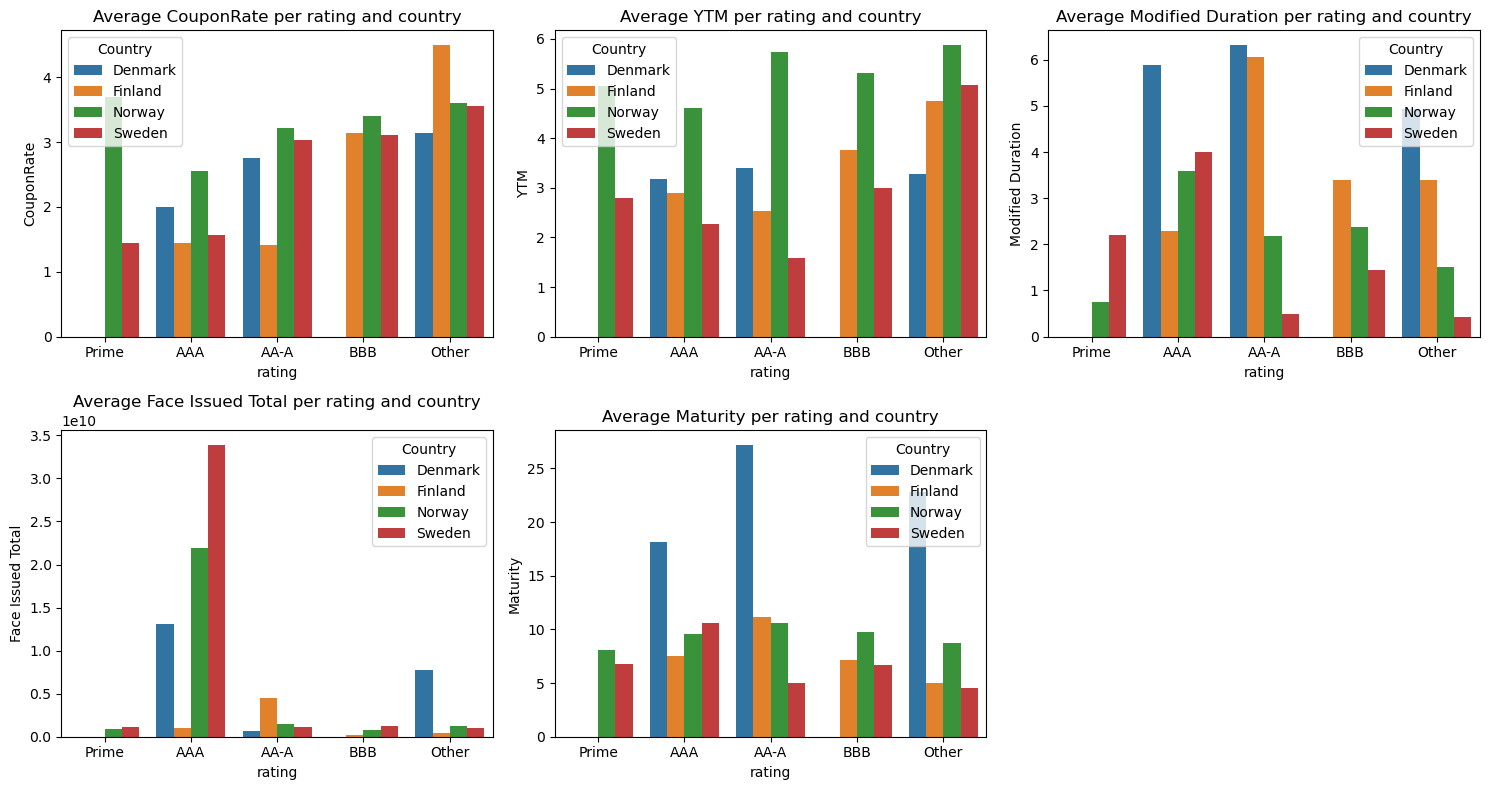

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt 

fig, axes = plt.subplots(2,3, figsize = (15,8))

axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.barplot(data=average, x='rating', y=average[col], hue=average['Country'], ax=ax)
    ax.set_title(f"Average {col} per rating and country")

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

#### Some observations:

##### Coupon

There is an interesting tendency shown in case of Finnish and Swedish bonds, the lower the rating is, the higher average coupon rate becomes. This does make sense as the riskier bonds should compensate the investors with higher coupon payments. Trend is not that drastically visible in case of Norwegian and Danish bonds, but still such concklusion is still applicable, with exception of Prime bonds for Norway

##### YTM

Again, Norway seems to have different pattern than e.g. Finland or Sweden - it has the highest YTM values across all rating buckets. If we check Sweden or Finland, the YTM is highest in case of BBB and Other categories of the bonds, which as well makes sense as in the previous point. Logically, AAA rated bonds have lower YTM. YTM appears to move in a direction that is broadly consistent with risk differentiation, suggesting a solid reason to include the estimator to the classification model. 

At the same time, the country effect is strong. That means the model may learn both differences in credit quality and differences in national bond market environments.

##### Modified Duration

The pattern is more mixed than in comparison to CouponRate or YTM. Denmark has the highest scores of modified duration across all rating buckets. It means that Danish bond prices are most sensitive to the interest rate changes, which might also determine the rating classification. AA-A rating has the highest sensitivity, Finland is almost at par with Sweden. One interesting feature is that duration seems especially high in some stronger rating categories. That is not a surprise as highly rated bonds may simply be issued with longer maturities or lower coupons, which mechanically increases duration.

##### Maturity

Indeed, higher rating bonds (AAA and AA-A) have a slightly higher maturity time than the lower rating bonds. This kind of supports the statement that higher rating bonds have the higher duration which coincides with the higher maturity time. Denmark again shows the highest scores acorss the board, so geographical factor indeed will play a role in the model.



# 5. Feature normalization for classification models

### 5.1. Remapping the IsCallable to binary outcome 

In [43]:
bond_ml['IsCallable'] = bond_ml['IsCallable'].astype(int)

### 5.2. Label Encoder for the categorical variables

In [44]:
from sklearn.preprocessing import LabelEncoder

le_rating = LabelEncoder()
bond_ml['rating'] = le_rating.fit_transform(bond_ml['rating'])

le_country = LabelEncoder()
bond_ml['Country'] = le_country.fit_transform(bond_ml['Country'])

le_sector_std = LabelEncoder()
bond_ml['sector_std'] = le_sector_std.fit_transform(bond_ml['sector_std'])


### 5.3. Standard scaler to numerical variables

In [45]:
from sklearn.preprocessing import StandardScaler

standardized_cols = ['YTM', 'Modified Duration', 'CouponRate', 'Face Issued Total', 'Maturity']
scaler_standard = StandardScaler()

bond_ml[standardized_cols] = scaler_standard.fit_transform(bond_ml[standardized_cols])

In [46]:
display(bond_ml.head())
print(bond_ml.shape)

,Country,CouponRate,YTM,Modified Duration,Face Issued Total,IsCallable,rating,sector_std,Maturity
0,0,1.931316,-0.241189,-0.897512,-0.217268,1,3,2,1.522918
1,0,1.931316,0.140273,-0.557359,2.790699,1,3,2,1.534196
2,0,2.525717,0.105867,-0.556822,1.368374,1,3,2,1.534196
4,0,1.336916,0.039714,-0.555787,0.085216,1,3,2,1.382374
5,0,1.336916,0.117619,-0.203087,-0.152233,1,3,2,1.571501


(860, 9)


# 6. Statistical learning

## 6.1. Supervised learning 

### 6.1.1. Train-validation-test splits

In [47]:
from sklearn.model_selection import train_test_split

rand_state = 100

y = bond_ml['rating']
X = bond_ml.drop(columns=['rating'])

#80-20 Train-test set 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand_state)

print("Train set size:", X_train.shape[0])
print()
print("Test set size:", X_test.shape[0])

Train set size: 688

Test set size: 172


In [48]:
print("Target label balance:")
pd.crosstab(bond_ml['rating'], bond_ml['rating'], normalize='all').reset_index(drop=True)

Target label balance:


rating,0,1,2,3,4
0,0.25,0.000000,0.000000,0.000000,0.000000
1,0.00,0.268605,0.000000,0.000000,0.000000
2,0.00,0.000000,0.133721,0.000000,0.000000
3,0.00,0.000000,0.000000,0.334884,0.000000
4,0.00,0.000000,0.000000,0.000000,0.012791


### 6.1.2. Motivation for model selection

I will proceed with the following models to classify the rating of the bond:

1. **Logistics Regression** - baseline model. Regressions in general are used as baseline models. It is simple and interpretable. 
2. **Random forests** - tree based ensemble methods are in general also easy to interpet. Random forests improves the basic classification tree by applying bootstrap with replacement which is super suitable in my case as I had to strip many observations from the dataset because LSEG was not in good mood. Moreover, it randomly selects the subset of the features, and in current setup have some variables which might not play a significant role like Maturity or Amount Issued. 

### 6.1.3. Setting up hyperparameters for the chosen models

In [49]:
rf_param_grid = {
    "n_estimators": [100, 200, 500, 800], #number of fitted trees
    "min_samples_leaf": [1, 2, 5, 10, 20], #minimum number of observations per each leaf
    "max_leaf_nodes": [None, 10, 20, 50, 100], #maximum number of leaves per each tree
    "max_depth": [None, 5, 10, 20] #number of main splits allowed per tree
}

In [50]:
logit_param_grid = {
    "penalty": ['l1', 'l2'],
    "C": [0.001, 0.01, 0.1, 1, 10, 100], #regularization strength, complexity parameter
    "solver": ["liblinear"]
}

### 6.1.4. Training and validating models using cross-validation

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_supervised = []

##### Random forests

In [52]:
grid_rf = GridSearchCV(RandomForestClassifier(random_state=rand_state), rf_param_grid, cv=5, scoring="f1_weighted", n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best RF parameters are:", grid_rf.best_params_)
print("Best RF Weighted F1 (CV):",f"{grid_rf.best_score_:.4f}")

y_pred_rf_tuned = grid_rf.best_estimator_.predict(X_test)

Best RF parameters are: {'max_depth': None, 'max_leaf_nodes': 100, 'min_samples_leaf': 1, 'n_estimators': 100}
Best RF Weighted F1 (CV): 0.6716


In [53]:
rf_val_f1_weighted = f1_score(y_test, y_pred_rf_tuned, average="weighted")
print("RF Weighted F1 (Validation):", f"{rf_val_f1_weighted:.4f}")

results_supervised.append({
        "Model": "RF",
        "Method": "CV Grid",
        "Params": grid_rf.best_params_,
        "Recall": round(recall_score(y_test, y_pred_rf_tuned, average="weighted"),3),
        "Accuracy": round(accuracy_score(y_test, y_pred_rf_tuned),3),
        "Precision": round(precision_score(y_test, y_pred_rf_tuned, average="weighted"),3),
        "F1": round(f1_score(y_test, y_pred_rf_tuned, average="weighted"),3)
         })

RF Weighted F1 (Validation): 0.5604


##### Logistics Regression

In [54]:
from sklearn.linear_model import LogisticRegression

grid_logit = GridSearchCV(LogisticRegression(max_iter=500, class_weight="balanced", random_state=rand_state), logit_param_grid, 
                                                cv=5, scoring="f1_weighted",n_jobs=-1)

grid_logit.fit(X_train, y_train)

print("Best logistics regression parameters are:", grid_logit.best_params_)
print("Best LR Weighted F1 (CV):", f"{grid_logit.best_score_:.4f}")

y_pred_logit_tuned = grid_logit.best_estimator_.predict(X_test)

Best logistics regression parameters are: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best LR Weighted F1 (CV): 0.5195


In [55]:
logit_val_f1_weighted = f1_score(y_test, y_pred_logit_tuned, average="weighted")
print("Logistics Reg Weighted F1 (Validation):", f"{logit_val_f1_weighted:.4f}")

results_supervised.append({
        "Model": "LogReg",
        "Method": "CV Grid",
        "Params": grid_logit.best_params_,
        "Recall": round(recall_score(y_test, y_pred_logit_tuned, average="weighted"),3),
        "Accuracy": round(accuracy_score(y_test, y_pred_logit_tuned),3),
        "Precision": round(precision_score(y_test, y_pred_logit_tuned, average="weighted"),3),
        "F1": round(f1_score(y_test, y_pred_logit_tuned, average="weighted"),3)
         })

Logistics Reg Weighted F1 (Validation): 0.4115


## 6.2. Unsupervised Learning

### 6.2.1. Drop rating column to avoid clustering distortion

Here I create a new version of already pre-processed `bond_ml` where variables are already label encoded and scaled to standard. 
After clustering I will decode them back to depict true values on the clusters.

In [56]:
bond_ml_cluster = bond_ml.drop(columns=['rating'])

### 6.2.2. Fit 3 clusters into the preprocessed data

In [57]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, random_state=rand_state, n_init=20)
bond_ml_cluster['cluster'] = kmeans.fit_predict(bond_ml_cluster)
bond_ml_cluster['cluster'].value_counts().sort_index()

cluster
0    104
1    427
2    329
Name: count, dtype: int64

### 6.2.3. Decode categorical and numerical variables back 

In [58]:
# Append back the dropped column rating based on the pandas index
bond_ml_cluster["rating"] = bond_ml.loc[bond_ml_cluster.index, "rating"]

In [59]:
bond_ml_cluster["rating"] = le_rating.inverse_transform(bond_ml["rating"])
bond_ml_cluster["Country"] = le_country.inverse_transform(bond_ml["Country"])
bond_ml_cluster["sector_std"] = le_sector_std.inverse_transform(bond_ml["sector_std"])
bond_ml_cluster[standardized_cols] = scaler_standard.inverse_transform(bond_ml[standardized_cols])

In [60]:
bond_ml_cluster

,Country,CouponRate,YTM,Modified Duration,Face Issued Total,IsCallable,sector_std,Maturity,cluster,rating
0,Denmark,6.000,2.543210,0.154932,3.926557e+09,1,Financials,32.72,1,Other
1,Denmark,6.000,4.076302,1.587514,5.184584e+10,1,Financials,32.85,1,Other
2,Denmark,7.000,3.938024,1.589776,2.918708e+10,1,Financials,32.85,1,Other
4,Denmark,5.000,3.672154,1.594135,8.745365e+09,1,Financials,31.10,1,Other
5,Denmark,5.000,3.985255,3.079560,4.962614e+09,1,Financials,33.28,1,Other
...,...,...,...,...,...,...,...,...,...,...
1218,Sweden,0.125,0.406037,0.072076,8.408000e+10,0,Sovereign/Public,10.30,0,AAA
1219,Sweden,0.125,1.466409,1.559564,3.621900e+10,0,Sovereign/Public,10.82,0,AAA
1220,Sweden,0.125,1.082299,4.037602,2.469100e+10,0,Sovereign/Public,10.31,0,AAA
1221,Sweden,0.125,1.246224,12.867402,1.241650e+10,0,Sovereign/Public,17.75,0,AAA


# 7. Result summary and export

## 7.1. Supervised learning results and summary

### 7.1.1. Random Forests

#### Classification report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\nClassification report RF (test):")
rf_classification_report_text = classification_report(
    y_test,
    y_pred_rf_tuned,
    target_names=le_rating.classes_
)
print(rf_classification_report_text)

rf_classification_report_dict = classification_report(
    y_test,
    y_pred_rf_tuned,
    target_names=le_rating.classes_,
    output_dict=True
)

rf_classification_report_df = pd.DataFrame(rf_classification_report_dict).transpose()


Classification report RF (test):
              precision    recall  f1-score   support

        AA-A       0.58      0.60      0.59        43
         AAA       0.64      0.41      0.50        51
         BBB       0.52      0.94      0.67        16
       Other       0.57      0.61      0.59        59
       Prime       0.00      0.00      0.00         3

    accuracy                           0.57       172
   macro avg       0.46      0.51      0.47       172
weighted avg       0.58      0.57      0.56       172



#### Confusion matrix


Confusion matrix RF (test):


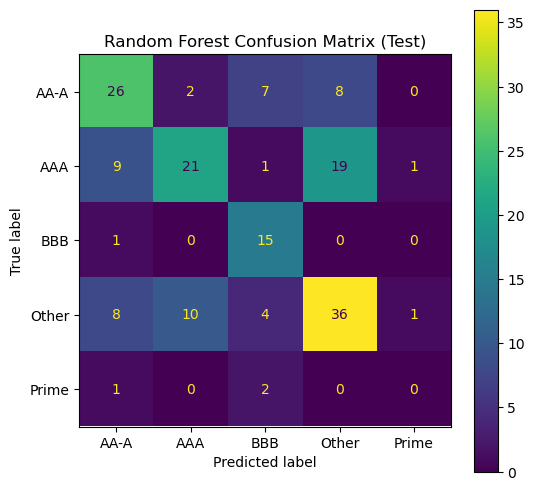

In [77]:
print("\nConfusion matrix RF (test):")

rf_confusion_matrix = confusion_matrix(y_test, y_pred_rf_tuned)

rf_confusion_matrix_df = pd.DataFrame(
    rf_confusion_matrix,
    index=le_rating.classes_,
    columns=le_rating.classes_
)

rf_confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=rf_confusion_matrix,
    display_labels=le_rating.classes_

)

fig_rf_confusion_matrix, ax_rf_confusion_matrix = plt.subplots(figsize=(6, 6))
rf_confusion_matrix_display.plot(ax=ax_rf_confusion_matrix)
ax_rf_confusion_matrix.set_title("Random Forest Confusion Matrix (Test)")
plt.show()

### 7.1.2. LogReg

#### Classification report

In [ ]:
print("\nClassification report LogReg (test):")
logreg_classification_report_text = classification_report(
    y_test,
    y_pred_logit_tuned,
    target_names=le_rating.classes_
)
print(logreg_classification_report_text)


logreg_classification_report_dict = classification_report(
    y_test,
    y_pred_logit_tuned,
    target_names=le_rating.classes_,
    output_dict=True
)

logreg_classification_report_df = pd.DataFrame(logreg_classification_report_dict).transpose()


Classification report LogReg (test):
              precision    recall  f1-score   support

        AA-A       0.42      0.26      0.32        43
         AAA       0.45      0.29      0.36        51
         BBB       0.22      0.50      0.30        16
       Other       0.57      0.58      0.57        59
       Prime       0.06      0.33      0.11         3

    accuracy                           0.40       172
   macro avg       0.34      0.39      0.33       172
weighted avg       0.46      0.40      0.41       172



#### Confusion matrix


Confusion matrix LogReg (test):


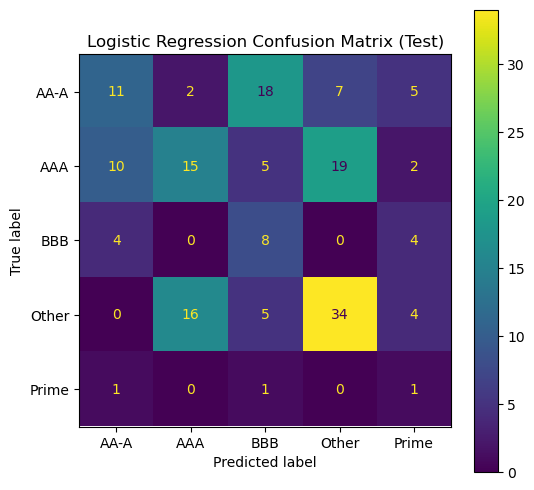

In [79]:
print("\nConfusion matrix LogReg (test):")
logreg_confusion_matrix = confusion_matrix(y_test, y_pred_logit_tuned)

logreg_confusion_matrix_df = pd.DataFrame(
    logreg_confusion_matrix,
    index=le_rating.classes_,
    columns=le_rating.classes_
)

logreg_confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=logreg_confusion_matrix,
    display_labels=le_rating.classes_
)

fig_logreg_confusion_matrix, ax_logreg_confusion_matrix = plt.subplots(figsize=(6, 6))
logreg_confusion_matrix_display.plot(ax=ax_logreg_confusion_matrix)
ax_logreg_confusion_matrix.set_title("Logistic Regression Confusion Matrix (Test)")
plt.show()

In [63]:
results_supervised = pd.DataFrame(results_supervised).sort_values("Recall", ascending=False).reset_index(drop=True)
results_supervised

,Model,Method,Params,Recall,Accuracy,Precision,F1
0,RF,CV Grid,"{'max_depth': None, 'max_leaf_nodes': 100, 'mi...",0.570,0.570,0.577,0.560
1,LogReg,CV Grid,"{'C': 100, 'penalty': 'l1', 'solver': 'libline...",0.401,0.401,0.456,0.412


In [75]:
bond_ml['rating'].value_counts()

rating
3    288
1    231
0    215
2    115
4     11
Name: count, dtype: int64

### Summary 

The supervised learning results show that the Random Forest classifier outperformed Logistic Regression in the multiclass bond rating classification task. This can be seen across all main evaluation metrics. Random Forest improved recall by roughly 17 percentage points and weighted precision by about 12 percentage points relative to Logistic Regression.

This result is not surprising given the structure of the dataset. The relationship between bond characteristics and rating categories is unlikely to be purely linear. Logistic Regression is a useful benchmark because it is simple and interpretable, but it is limited in its ability to capture such nonlinear interactions. Random Forest, by contrast, is designed to model more complex relationships and is therefore better suited to this type of financial classification problem.

At the class level, the Random Forest model performed especially well for the BBB class, where recall reached 0.94 and the F1-score reached 0.67. The AA-A and Other classes were also classified reasonably well, with F1-scores close to 0.59. The class imbalance of the target variable also matters here. The Other, AAA, and AA-A groups have the largest number of observations, while BBB is smaller but still got identified pretty well. 

A likely reason why Random Forest performed better is that the final modeling dataset became substantially smaller after filtering out observations with missing target ratings. In such a setting, Random Forest can still work well because it uses bootstrap aggregation.
The selected hyperparameters also support this interpretation. The best Random Forest configuration used no maximum depth limit together with a cap on the number of leaf nodes. This suggests that the model benefited from relatively flexible trees capable of learning complex decision boundaries.

Overall, the supervised learning results indicate that Random Forest is the more suitable (out of the two models tested) for this multiclass bond rating classification task. However, the results also show that the problem remains challenging, mainly because of class imbalance, a small effective sample size after cleaning, and substantial overlap across rating groups.

## 7.2 Unsupervised learning results and summary

### 7.2.1. Numerical feature analysis grouped into clusters

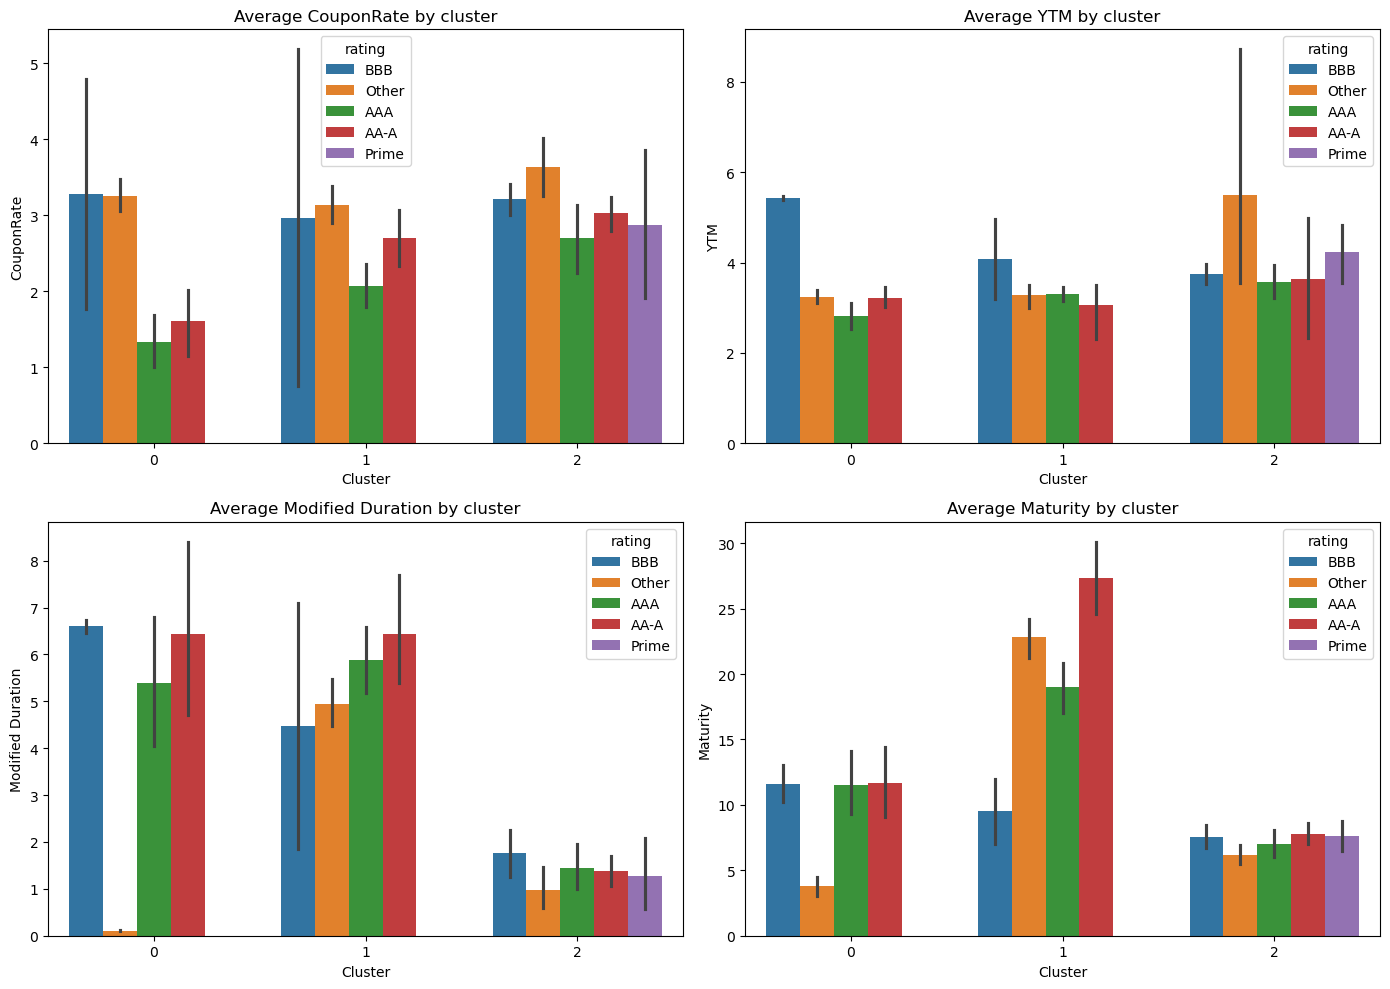

In [64]:
numeric_cols = ["CouponRate", "YTM", "Modified Duration", "Maturity"]

fig_cluster_numeric, axes_cluster_numeric = plt.subplots(2, 2, figsize=(14, 10))
axes_cluster_numeric = axes_cluster_numeric.flatten()

for ax, col in zip(axes_cluster_numeric, numeric_cols):
    sns.barplot(data=bond_ml_cluster, x="cluster", y=col, estimator="mean", ax=ax, hue='rating')
    ax.set_title(f"Average {col} by cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

### 7.2.3. Categorical variable analysis grouped into clusters

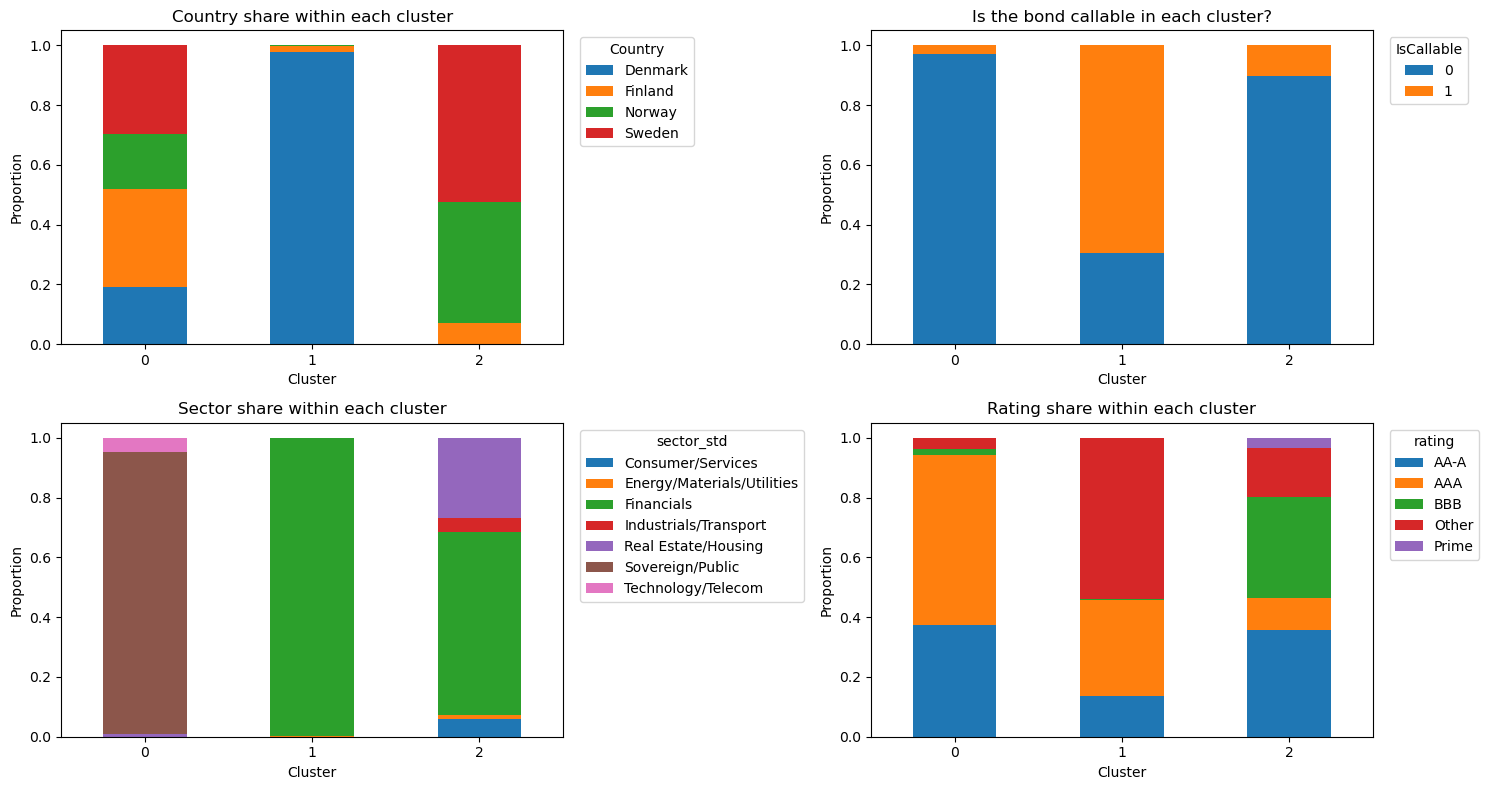

In [65]:
categorical_cols = {
    "Country": "Country share within each cluster",
    "IsCallable": "Is the bond callable in each cluster?",
    "sector_std": "Sector share within each cluster",
    "rating": "Rating share within each cluster",
}


fig_cluster_categorical, axes_cluster_categorical = plt.subplots(2, 2, figsize=(15, 8))
axes_cluster_categorical = axes_cluster_categorical.flatten()

axes = axes.flatten()
for ax, (col, title) in zip(axes_cluster_categorical, categorical_cols.items()):
    
    ct = pd.crosstab(
        bond_ml_cluster["cluster"],
        bond_ml_cluster[col],
        normalize="index"
    )

    ct.plot(kind="bar", stacked=True, ax=ax, legend=True)

    ax.set_title(title)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title=col, bbox_to_anchor=(1.02, 1), loc="upper left")


plt.tight_layout()
plt.show()

### 7.2.4 Executive summary per cluster

In [66]:
numeric_cols = ["CouponRate", "YTM", "Modified Duration", "Face Issued Total", "Maturity"]

#Prepare the numeric col summary grouped by cluster 
cluster_numeric_summary = (bond_ml_cluster.groupby("cluster")[numeric_cols].mean().round(2).reset_index())

In [67]:
# Define the custom function to identify the top categorical labels across clusters 
def top_category_with_share(df, group_col, cat_col):

    #First group by the cluster and the desired column to check the counts
    counts = (df.groupby([group_col, cat_col]).size().reset_index(name="count"))

    #Check total counts per cluster
    totals = (df.groupby(group_col).size().reset_index(name="total_count"))

    #Append the total counts to the counts per cluster and categorical columns
    #to calculate the share of the categorical label
    merged = counts.merge(totals, on=group_col, how="left")
    merged["share"] = merged["count"] / merged["total_count"]

    #Identify the top label across the cluster
    top = (merged.sort_values([group_col, "count"], ascending=[True, False]).groupby(group_col, as_index=False).first())

    #Filter only necessary columns in the prepared summary, rename them
    top = top[[group_col, cat_col, "share"]]
    top = top.rename(columns={
        cat_col: f"top_{cat_col}",
        "share": f"{cat_col}_share"
    })

    return top

#Produce the data frames per each categorical variable across clusters
country_top = top_category_with_share(bond_ml_cluster, "cluster", "Country")
sector_top = top_category_with_share(bond_ml_cluster, "cluster", "sector_std")
rating_top = top_category_with_share(bond_ml_cluster, "cluster", "rating")
callable_top = top_category_with_share(bond_ml_cluster, "cluster", "IsCallable")

country_top

,cluster,top_Country,Country_share
0,0,Finland,0.326923
1,1,Denmark,0.978923
2,2,Sweden,0.522796


In [68]:
#Produce the dataframe of the cluster sizes
cluster_sizes = (bond_ml_cluster["cluster"].value_counts().sort_index().rename_axis("cluster").reset_index(name="cluster_size"))
cluster_sizes

,cluster,cluster_size
0,0,104
1,1,427
2,2,329


In [69]:
# Append all produced bits and pieces into the executive summary
cluster_exec_summary = (
    cluster_sizes
    .merge(cluster_numeric_summary, on="cluster", how="left")
    .merge(country_top, on="cluster", how="left")
    .merge(sector_top, on="cluster", how="left")
    .merge(rating_top, on="cluster", how="left")
    .merge(callable_top, on="cluster", how="left")
)

share_cols = [col for col in cluster_exec_summary.columns if col.endswith("_share")]
cluster_exec_summary[share_cols] = cluster_exec_summary[share_cols].round(2)

display(cluster_exec_summary)

,cluster,cluster_size,CouponRate,YTM,Modified Duration,Face Issued Total,Maturity,top_Country,Country_share,top_sector_std,sector_std_share,top_rating,rating_share,top_IsCallable,IsCallable_share
0,0,104,1.55,3.03,5.61,2.844876e+10,11.29,Finland,0.33,Sovereign/Public,0.94,AAA,0.57,0,0.97
1,1,427,2.74,3.26,5.45,7.002365e+09,22.13,Denmark,0.98,Financials,1.00,Other,0.54,1,0.69
2,2,329,3.15,3.99,1.44,1.230484e+09,7.35,Sweden,0.52,Financials,0.61,AA-A,0.36,0,0.90


### Summary

Several values for the number of clusters were tested, but the **3-cluster solution** appears to be the most interpretable and economically meaningful. When the number of clusters is increased beyond three, the structure becomes less clear: Denmark starts to dominate more than one large cluster, while Norway only emerges more distinctly when as many as five clusters are imposed. This suggests that increasing the number of clusters adds fragmentation without necessarily improving interpretability.

Overall, the clustering results appear sensible and informative. The algorithm was able to separate the bond universe into three distinct profiles, and these profiles are not random.

##### **Geographical separation**
A particularly strong result is the geographical separation. The three clusters correspond quite clearly to different Nordic country profiles:

- Cluster 0 is mainly associated with Finland
- Cluster 1 is almost entirely dominated by Denmark
- Cluster 2 is primarily associated with Sweden, with some Norwegian presence

##### Sector composition
The sector composition is also economically intuitive. The dataset overall is heavily tilted toward Financials, and this is reflected in the clustering. In particular:

- Cluster 1 is fully dominated by Financials
- Cluster 2 is also mainly Financials, although with more variation, including some real estate and a small share of other sectors
- Cluster 0 stands out because it is heavily dominated by Sovereign/Public instruments, with a share of roughly 94%

This means that the model is not merely separating observations by country, but is also distinguishing between very different types of fixed income instruments, particularly sovereign/public versus financial-sector bonds.

##### **Rating composition**
The rating composition also supports the quality of the clustering. The clusters are not pure rating buckets, but they do show clear dominance patterns:

- Cluster 0 is mainly associated with AAA
- Cluster 1 is mainly associated with Other
- Cluster 2 is mainly associated with AA-A

This is a useful result, because it shows that the unsupervised algorithm is able to recover some meaningful credit-quality structure even though rating was not the direct objective of the clustering. 

##### **Numerical characteristics**
Looking at the numerical summaries, the clusters are also distinguishable in terms of their bond characteristics:

- Cluster 0 has the lowest coupon rate on average, moderate YTM, and relatively high modified duration. This is consistent with its sovereign/public and AAA-dominated structure.
- Cluster 1 stands out most clearly in terms of maturity, with an average maturity of more than 22 years, far above the other clusters. This confirms the visual EDA observation that the Danish-dominated cluster contains especially long-dated instruments.
- Cluster 2 has the highest coupon rate and highest YTM, but the lowest modified duration and shorter maturity. This suggests a profile of shorter-duration, higher-yield bonds, which fits with its mixed but predominantly financial and AA-A structure.


##### **Overall**
Overall, the clustering exercise can be considered successful. The three-cluster solution produces groups that are economically interpretable and consistent with the earlier exploratory data analysis. The algorithm identifies distinct bond buckets based on a combination of structural bond features and market characteristics. Even though clustering does not have a formal “accuracy” metric in the same way as supervised learning, the resulting profiles are coherent enough to conclude that the method works well for separating the bonds into meaningful types.

In summary, the unsupervised learning results suggest that the bond universe can be segmented into three broad clusters:

1. a Finnish sovereign/public, higher-quality cluster
2. a Danish long-maturity financial cluster
3. a Swedish-dominated financial cluster with higher yields and shorter duration

This confirms that clustering is a useful way to identify broad bond risk profiles even without explicitly predicting ratings.

## 7.3. Export the analytics

In [ ]:
# Output the pre-processed merged outputs from LSEG
from pathlib import Path

output_dir = Path("outputs/datasets")
output_dir.mkdir(parents=True, exist_ok=True)

#bond_clean_df.to_excel(output_dir / "bond_clean.xlsx", index=False)

In [ ]:
# Output the clean and ready for supervised ML bond dataset
#bond_ml.to_excel("outputs/datasets/bond_ml.xlsx")

In [ ]:
# Output the unsupervised ML cluster lables dataset of bond_ml
#bond_ml_cluster.to_excel("outputs/datasets/bond_ml_cluster.xlsx")

In [ ]:
# Output the supervised ML classification reports
output_dir = Path("outputs/analytics")
output_dir.mkdir(parents=True, exist_ok=True)

#rf_classification_report_df.to_excel("outputs/analytics/rf_classification_report.xlsx")
#logreg_classification_report_df.to_excel("outputs/analytics/logreg_classification_report.xlsx")

In [ ]:
# Output the supervised ML confusion matrices to excel
#rf_confusion_matrix_df.to_excel("outputs/analytics/rf_confusion_matrix.xlsx")
#logreg_confusion_matrix_df.to_excel("outputs/analytics/logreg_confusion_matrix.xlsx")

In [ ]:
# Output the summary of the cluster analysis
#cluster_exec_summary.to_excel(output_dir / "cluster_analysis.xlsx", index=False)

In [ ]:
#output the confusion matrix plots
output_dir = Path("outputs/plots")
output_dir.mkdir(parents=True, exist_ok=True)

#fig_rf_confusion_matrix.savefig("outputs/plots/rf_confusion_matrix.png", dpi=300, bbox_inches="tight")
#fig_logreg_confusion_matrix.savefig("outputs/plots/logreg_confusion_matrix.png", dpi=300, bbox_inches="tight")

In [ ]:
# Output the unsupervised ML output plots

#fig_cluster_numeric.savefig(output_dir / "cluster_numeric.png", dpi=300, bbox_inches="tight")
#fig_cluster_categorical.savefig(output_dir / "cluster_categorical.png", dpi=300, bbox_inches="tight")